# QoSBuddy

## 1-Data Acquisition and Understanding: 

Starting with loading and exploring the chosen dataset from Zenodo. This dataset provides QoS metrics from 5G campus networks, including one-way delay, throughput, jitter, and packet loss, which align with our project's goals for network performance monitoring and anomaly detection.

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

# ── QoSBuddy colour palette ──────────────────────────────────────────────────
PALETTE = {
    'primary':   '#6C63FF',
    'secondary': '#00D4FF',
    'accent':    '#FF6BDA',
    'success':   '#00E5A0',
    'warning':   '#FFB347',
    'danger':    '#FF4D6D',
    'neutral':   '#8892B0',
}

SCENARIO_COLORS = {
    'normal':               '#00E5A0',
    'network_congestion':   '#FF4D6D',
    'rf_interference':      '#FFB347',
    'handover_failure':     '#FF6BDA',
    'link_saturation':      '#6C63FF',
    'backhaul_degradation': '#00D4FF',
}

# ── Global matplotlib dark theme ─────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0E1120',
    'axes.facecolor':   '#131625',
    'axes.edgecolor':   '#2A2F4A',
    'axes.labelcolor':  '#C8CAE8',
    'axes.titlecolor':  '#E8EAFF',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'axes.grid':        True,
    'grid.color':       '#1E2340',
    'grid.linewidth':   0.6,
    'xtick.color':      '#8892B0',
    'ytick.color':      '#8892B0',
    'text.color':       '#E8EAFF',
    'legend.facecolor': '#131625',
    'legend.edgecolor': '#2A2F4A',
    'legend.fontsize':  10,
    'figure.dpi':       110,
})
sns.set_palette(list(PALETTE.values()))

%matplotlib inline
print("✅ Imports & QoSBuddy dark theme configured")


✅ Imports & QoSBuddy dark theme configured


Since the dataset 'ntnu_owd_all_Packets.csv' is large (approximately 2.7 GB) and contains packet-level data from 5G network measurements, we'll load a sample of the first 1,000,000 rows for initial exploration to avoid memory issues. This allows us to inspect the structure, columns, and data types.

In [89]:
# Define the file path 
file_path = "ntnu_owd_all_Packets.csv"


# Load sample with proper handling for mixed-type IP columns
df_sample = pd.read_csv(
    file_path, 
    nrows=1000000,
    dtype={'SourceIPOuter': 'string', 'DestinationIPOuter': 'string'},
    low_memory=False
)

print("Shape:", df_sample.shape)
df_sample.head()

Shape: (1000000, 23)


,Unnamed: 0,src,Timestamp,SourceIPOuter,DestinationIPOuter,SourceIPInner,DestinationIPInner,PacketSize,SeqNum,iat,...,bw,slots,ratio,pdist,piat,psize,pnpak,rep,scenario,direction
0,1,1ue,1.720191e+09,<NA>,<NA>,10.45.0.2,10.45.0.1,32,1,0.000000,...,20,10,2,det,1700,small,10000,1,oai_b200_20mhz_10slots_ratio2_det_01700_small_...,uplink
1,2,1ue,1.720191e+09,<NA>,<NA>,10.45.0.2,10.45.0.1,32,2,0.001712,...,20,10,2,det,1700,small,10000,1,oai_b200_20mhz_10slots_ratio2_det_01700_small_...,uplink
2,3,1ue,1.720191e+09,<NA>,<NA>,10.45.0.2,10.45.0.1,32,3,0.001652,...,20,10,2,det,1700,small,10000,1,oai_b200_20mhz_10slots_ratio2_det_01700_small_...,uplink
3,4,1ue,1.720191e+09,<NA>,<NA>,10.45.0.2,10.45.0.1,32,4,0.001694,...,20,10,2,det,1700,small,10000,1,oai_b200_20mhz_10slots_ratio2_det_01700_small_...,uplink
4,5,1ue,1.720191e+09,<NA>,<NA>,10.45.0.2,10.45.0.1,32,5,0.001704,...,20,10,2,det,1700,small,10000,1,oai_b200_20mhz_10slots_ratio2_det_01700_small_...,uplink


Now that the data is loaded, let's inspect its structure. This includes checking data types, non-null counts, and memory usage with .info(). We'll also list the columns for reference. This helps identify if any columns need type conversion (e.g., 'Timestamp' to datetime) or if there are missing values.

In [91]:
# Get data info
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 23 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   Unnamed: 0          1000000 non-null  int64  
 1   src                 1000000 non-null  object 
 2   Timestamp           1000000 non-null  float64
 3   SourceIPOuter       500000 non-null   string 
 4   DestinationIPOuter  500000 non-null   string 
 5   SourceIPInner       1000000 non-null  object 
 6   DestinationIPInner  1000000 non-null  object 
 7   PacketSize          1000000 non-null  int64  
 8   SeqNum              1000000 non-null  int64  
 9   iat                 1000000 non-null  float64
 10  trel                1000000 non-null  float64
 11  gnb                 1000000 non-null  object 
 12  sdr                 1000000 non-null  object 
 13  bw                  1000000 non-null  int64  
 14  slots               1000000 non-null  int64  
 15  ratio           

We first explore numerical columns: 

In [93]:
# Statistical summary of numerical columns
numerical_summary = df_sample.describe()
print("Numerical Features Summary:")
print(numerical_summary.round(2))

Numerical Features Summary:
       Unnamed: 0     Timestamp  PacketSize      SeqNum         iat  \
count  1000000.00  1.000000e+06  1000000.00  1000000.00  1000000.00   
mean    500000.50  1.720195e+09       63.89     5000.50        0.00   
std     288675.28  9.919260e+03       29.00     2886.75        0.00   
min          1.00  1.720180e+09       32.00        1.00       -0.00   
25%     250000.75  1.720188e+09       35.00     2500.75        0.00   
50%     500000.50  1.720192e+09       63.00     5000.50        0.00   
75%     750000.25  1.720205e+09       93.00     7500.25        0.00   
max    1000000.00  1.720212e+09       94.00    10000.00        0.06   

             trel         bw      slots      ratio       piat      pnpak  \
count  1000000.00  1000000.0  1000000.0  1000000.0  1000000.0  1000000.0   
mean         8.51       20.0       12.0        2.6     1700.0    10000.0   
std          4.91        0.0        4.0        1.2        0.0        0.0   
min          0.00       20.0

We explore the categorical features: 

In [95]:
# Identify categorical columns
categorical_cols = df_sample.select_dtypes(include=['object', 'string']).columns.tolist()

print(f"Categorical Features ({len(categorical_cols)} columns):\n")

# Display unique value counts for each categorical column
for col in categorical_cols:
    unique_count = df_sample[col].nunique()
    print(f"{col}: {unique_count} unique values")
    if unique_count <= 10:  # Show value counts for columns with few unique values
        print(df_sample[col].value_counts())
    print("-" * 60)

Categorical Features (11 columns):

src: 2 unique values
src
1ue     500000
2gnb    500000
Name: count, dtype: int64
------------------------------------------------------------
SourceIPOuter: 2 unique values
SourceIPOuter
11.10.0.2    250000
11.10.0.1    250000
Name: count, dtype: Int64
------------------------------------------------------------
DestinationIPOuter: 2 unique values
DestinationIPOuter
11.10.0.1    250000
11.10.0.2    250000
Name: count, dtype: Int64
------------------------------------------------------------
SourceIPInner: 2 unique values
SourceIPInner
10.45.0.2    500000
10.45.0.1    500000
Name: count, dtype: int64
------------------------------------------------------------
DestinationIPInner: 2 unique values
DestinationIPInner
10.45.0.1    500000
10.45.0.2    500000
Name: count, dtype: int64
------------------------------------------------------------
gnb: 1 unique values
gnb
oai    1000000
Name: count, dtype: int64
------------------------------------------------

In [96]:
# Analyze the experimental setup and data collection parameters
print("=" * 80)
print("DATA COLLECTION CONTEXT")
print("=" * 80)

# Network configuration parameters (from the fixed columns)
print("\nNetwork Configuration:")
print(f"  Bandwidth: {df_sample['bw'].unique()[0]} MHz")
print(f"  Time Slots: {df_sample['slots'].unique()[0]}")
print(f"  Slot Ratio: {df_sample['ratio'].unique()[0]}")
print(f"  Packet IAT: {df_sample['piat'].unique()[0]} µs")
print(f"  Packets per Rep: {df_sample['pnpak'].unique()[0]}")

# Experimental setup
print("\nExperimental Setup:")
print(f"  gNB Type: {df_sample['gnb'].unique()[0]}")
print(f"  SDR Hardware: {df_sample['sdr'].unique()[0]}")
print(f"  Packet Distribution: {df_sample['pdist'].unique()[0]}")
print(f"  Packet Size Profile: {df_sample['psize'].unique()[0]}")

# Repetitions and scenarios
print(f"\nRepetitions: {sorted(df_sample['rep'].unique())}")
print(f"Traffic Directions: {df_sample['direction'].unique().tolist()}")
print(f"Source Types: {df_sample['src'].unique().tolist()}")

DATA COLLECTION CONTEXT

Network Configuration:
  Bandwidth: 20 MHz
  Time Slots: 10
  Slot Ratio: 2
  Packet IAT: 1700 µs
  Packets per Rep: 10000

Experimental Setup:
  gNB Type: oai
  SDR Hardware: b200
  Packet Distribution: det
  Packet Size Profile: small

Repetitions: [1, 2, 3, 4, 5]
Traffic Directions: ['uplink', 'downlink']
Source Types: ['1ue', '2gnb']


**Data Collection Context - Simple Explanation**

**What is this dataset?**
This is experimental 5G network traffic data collected in a controlled lab environment using OpenAirInterface (OAI) software and USRP B200 hardware.

**Network Setup:**
- The 5G network was configured with 20 MHz bandwidth and 10 time slots
- Packets were sent at a fixed rate: one packet every 1,700 microseconds (1.7 milliseconds)
- Each experimental run generated 10,000 packets
- All packets are small (32-94 bytes based on our data)

**Experimental Design:**
- The same experiment was repeated 3 times (rep1, rep2, rep3) to ensure consistency
- Traffic flows in both directions:
  - **Uplink**: From mobile device (UE) to base station (gNB)
  - **Downlink**: From base station (gNB) to mobile device (UE)
- Two packet sources are captured: packets originating from the UE and packets originating from the gNB

**Key Insight:**
Most network parameters (bandwidth, slots, packet timing) remain constant across all measurements. This means they won't help us predict QoS issues, but they tell us the conditions under which the data was collected. We'll need to engineer new features from packet timing and sequence data to extract meaningful QoS metrics like jitter, packet loss, and throughput.

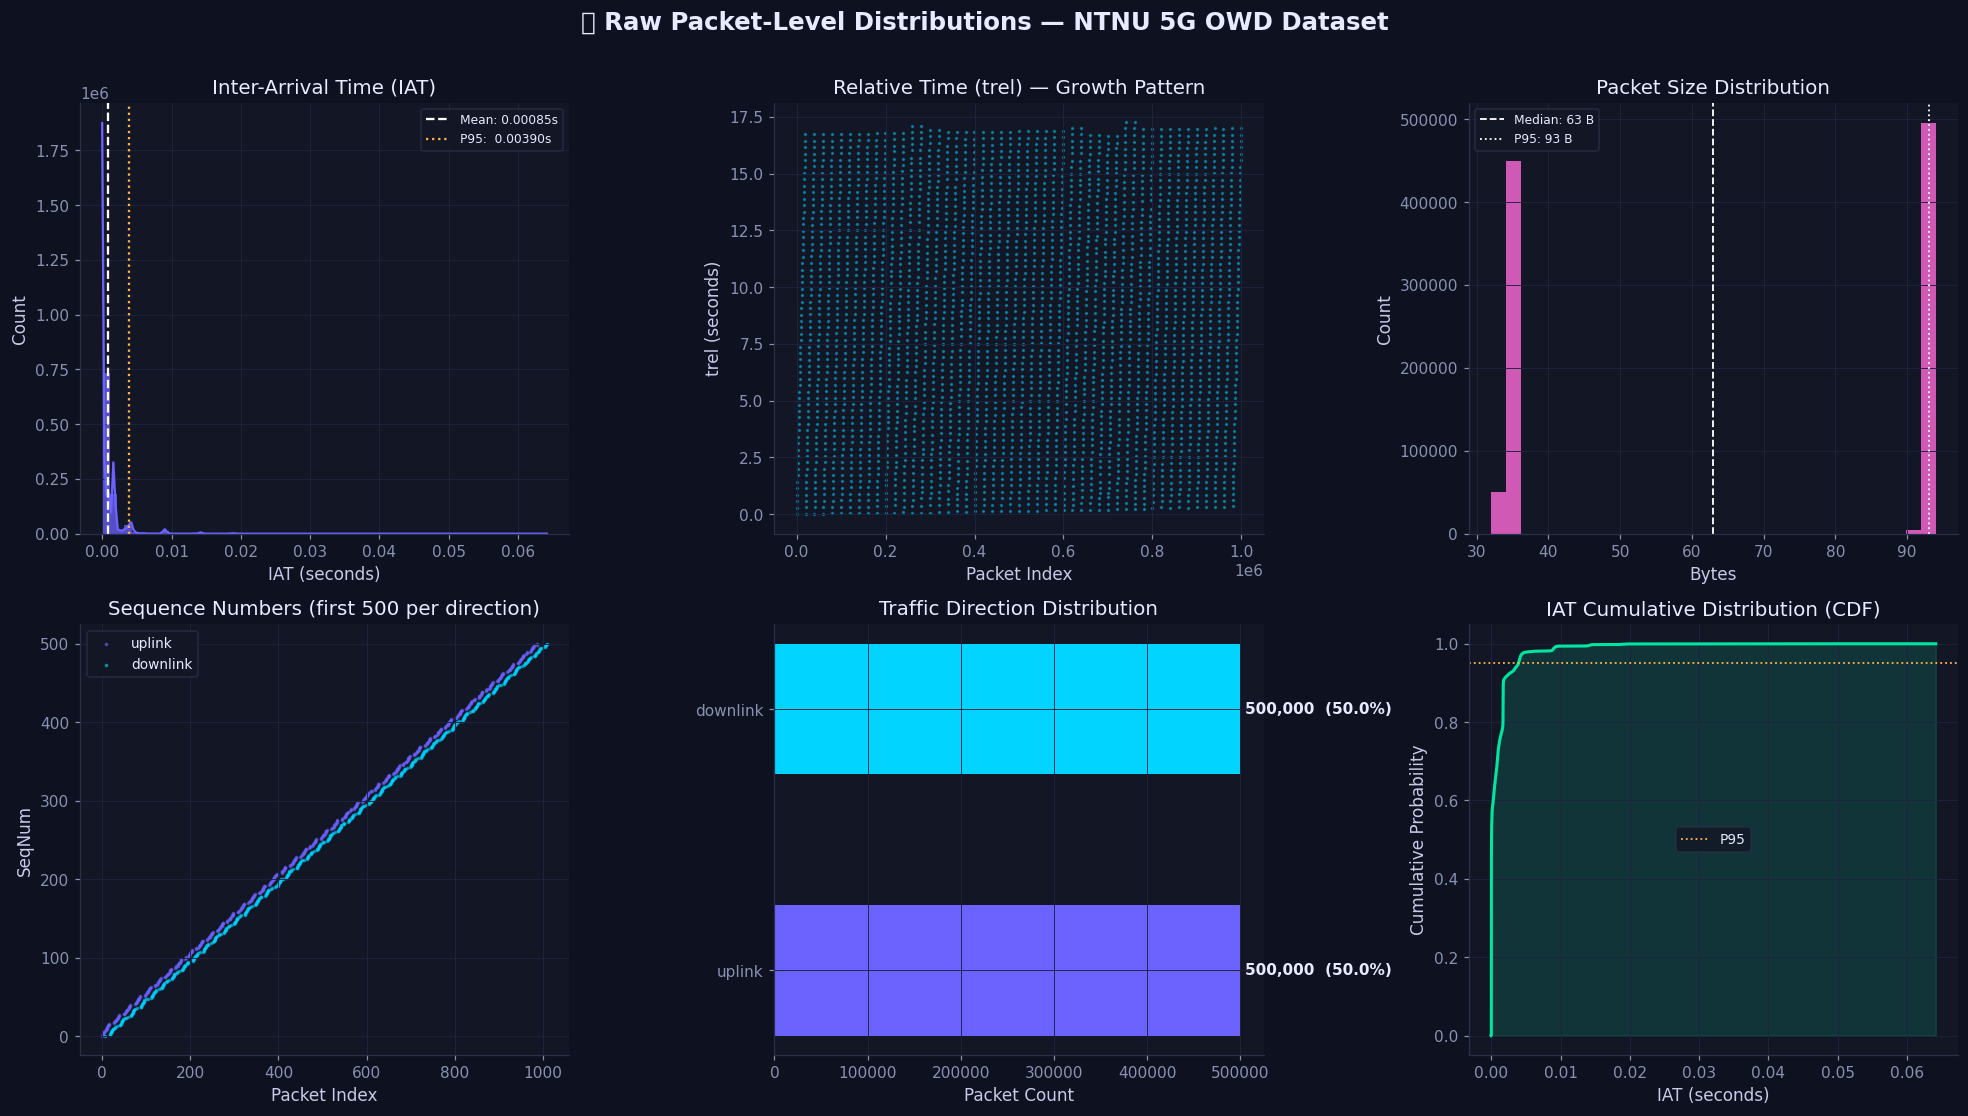

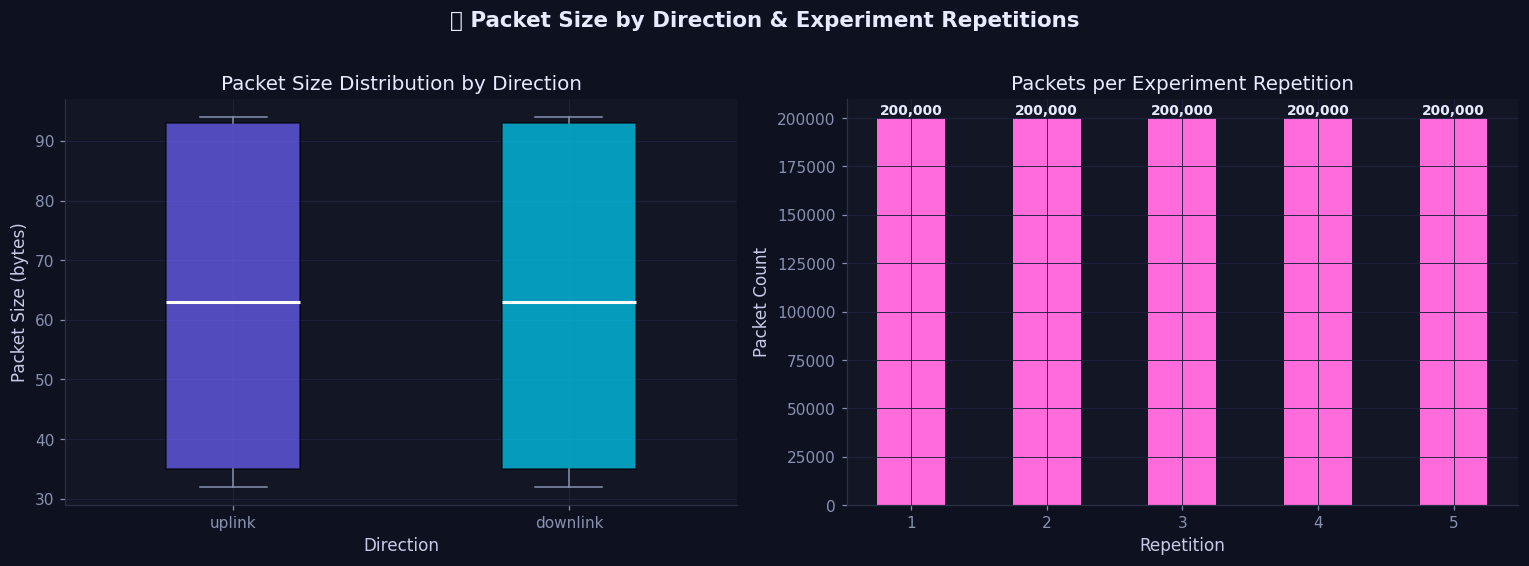

In [98]:
# ── VIZ 1 — Raw Packet-Level Distributions ───────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("📦 Raw Packet-Level Distributions — NTNU 5G OWD Dataset",
             fontsize=16, fontweight='bold', y=1.01)

# Panel 1: IAT histogram + KDE
sns.histplot(df_sample['iat'], bins=60, kde=True, ax=axes[0,0],
             color=PALETTE['primary'], edgecolor='none', alpha=0.75)
axes[0,0].axvline(df_sample['iat'].mean(), color='white', ls='--', lw=1.5,
                  label=f"Mean: {df_sample['iat'].mean():.5f}s")
axes[0,0].axvline(df_sample['iat'].quantile(0.95), color=PALETTE['warning'], ls=':', lw=1.5,
                  label=f"P95:  {df_sample['iat'].quantile(0.95):.5f}s")
axes[0,0].set_title('Inter-Arrival Time (IAT)'); axes[0,0].set_xlabel('IAT (seconds)')
axes[0,0].legend(fontsize=8)

# Panel 2: trel scatter (shows linear growth pattern)
sample_idx = np.linspace(0, len(df_sample)-1, 3000, dtype=int)
axes[0,1].scatter(sample_idx, df_sample['trel'].iloc[sample_idx],
                  s=1.5, alpha=0.4, color=PALETTE['secondary'])
axes[0,1].set_title('Relative Time (trel) — Growth Pattern')
axes[0,1].set_xlabel('Packet Index'); axes[0,1].set_ylabel('trel (seconds)')

# Panel 3: Packet size histogram
sns.histplot(df_sample['PacketSize'], bins=30, kde=False, ax=axes[0,2],
             color=PALETTE['accent'], edgecolor='none', alpha=0.8)
for pct, ls, label in [(0.5,'--','Median'), (0.95,':','P95')]:
    v = df_sample['PacketSize'].quantile(pct)
    axes[0,2].axvline(v, color='white', ls=ls, lw=1.2, label=f'{label}: {v:.0f} B')
axes[0,2].set_title('Packet Size Distribution'); axes[0,2].set_xlabel('Bytes')
axes[0,2].legend(fontsize=8)

# Panel 4: SeqNum — scatter coloured by direction (dynamic values)
dir_vals   = df_sample['direction'].dropna().unique().tolist()
dir_colors = [PALETTE['primary'], PALETTE['secondary'], PALETTE['accent']]
for direction, color in zip(dir_vals, dir_colors):
    mask = df_sample['direction'] == direction
    idx  = np.where(mask.values)[0][:500]
    vals = df_sample.loc[mask, 'SeqNum'].values[:500]
    axes[1,0].scatter(idx, vals, s=2, alpha=0.5, color=color, label=str(direction))
axes[1,0].set_title('Sequence Numbers (first 500 per direction)')
axes[1,0].set_xlabel('Packet Index'); axes[1,0].set_ylabel('SeqNum')
axes[1,0].legend(fontsize=9)

# Panel 5: Direction counts — horizontal bars
dir_counts = df_sample['direction'].value_counts()
bar_colors = [PALETTE['primary'], PALETTE['secondary'], PALETTE['accent']]
axes[1,1].barh(range(len(dir_counts)), dir_counts.values,
               color=bar_colors[:len(dir_counts)], edgecolor='none', height=0.5)
axes[1,1].set_yticks(range(len(dir_counts)))
axes[1,1].set_yticklabels(dir_counts.index.tolist())
for j, (val) in enumerate(dir_counts.values):
    axes[1,1].text(val + val*0.01, j,
                   f'{val:,}  ({val/len(df_sample)*100:.1f}%)',
                   va='center', fontsize=10, fontweight='bold')
axes[1,1].set_title('Traffic Direction Distribution')
axes[1,1].set_xlabel('Packet Count')

# Panel 6: IAT CDF
sorted_iat = np.sort(df_sample['iat'].dropna().values)
cdf_vals   = np.arange(1, len(sorted_iat)+1) / len(sorted_iat)
axes[1,2].plot(sorted_iat, cdf_vals, color=PALETTE['success'], lw=2)
axes[1,2].fill_between(sorted_iat, cdf_vals, alpha=0.15, color=PALETTE['success'])
axes[1,2].axhline(0.95, color=PALETTE['warning'], ls=':', lw=1.2, label='P95')
axes[1,2].set_title('IAT Cumulative Distribution (CDF)')
axes[1,2].set_xlabel('IAT (seconds)'); axes[1,2].set_ylabel('Cumulative Probability')
axes[1,2].legend(fontsize=9)

for ax in axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# ── VIZ 2 — Packet Size by Direction (boxplot) + Repetition bar ──────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("\U0001f500 Packet Size by Direction & Experiment Repetitions",
             fontsize=14, fontweight='bold', y=1.02)

# --- Left: Boxplot per direction (avoids violin empty-plot bug) ---
dir_vals   = df_sample['direction'].dropna().unique().tolist()
dir_colors = [PALETTE['primary'], PALETTE['secondary'], PALETTE['accent']]

# Group data per direction and plot manually
data_by_dir = [df_sample.loc[df_sample['direction']==d, 'PacketSize'].dropna().values
               for d in dir_vals]
bp = axes[0].boxplot(data_by_dir,
                     patch_artist=True,
                     widths=0.4,
                     medianprops={'color':'white','linewidth':2},
                     flierprops={'marker':'o','markersize':2,'alpha':0.3})
for patch, color in zip(bp['boxes'], dir_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for whisker in bp['whiskers']:
    whisker.set_color('#8892B0')
for cap in bp['caps']:
    cap.set_color('#8892B0')
axes[0].set_xticks(range(1, len(dir_vals)+1))
axes[0].set_xticklabels(dir_vals)
axes[0].set_title('Packet Size Distribution by Direction')
axes[0].set_xlabel('Direction'); axes[0].set_ylabel('Packet Size (bytes)')
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

# --- Right: Repetition bar (cast rep to str to ensure clean labels) ---
rep_series = df_sample['rep'].dropna().astype(str)
rep_counts = rep_series.value_counts().sort_index()
x_pos = range(len(rep_counts))
axes[1].bar(x_pos, rep_counts.values,
            color=PALETTE['accent'], edgecolor='none', width=0.5)
axes[1].set_xticks(list(x_pos))
axes[1].set_xticklabels(rep_counts.index.tolist())
for j, h in enumerate(rep_counts.values):
    axes[1].text(j, h + max(rep_counts.values)*0.01, f'{h:,}',
                 ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Packets per Experiment Repetition')
axes[1].set_xlabel('Repetition'); axes[1].set_ylabel('Packet Count')
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


**Data Quality Assessment - Key Observations**

**Inter-Arrival Time (IAT)**
- Heavily concentrated near 0 seconds (deterministic packet generation)
- Very few outliers with higher IAT values
- Confirms the 'deterministic' packet distribution setting

**Relative Time (trel)**
- Linear growth from 0 to ~17.5 seconds
- Uniform distribution indicates steady, continuous packet flow
- No major gaps or anomalies in timing

**Packet Size Distribution**
- Bimodal distribution: Two distinct packet sizes
- Small packets (~35 bytes) and larger packets (~93 bytes) observed
- Matches the 'small' packet size profile from experimental configuration

**Sequence Numbers**
- Perfect linear progression (no gaps observed in first 1000 packets)
- NO packet loss detected in this sample
- Excellent data quality indicator

**Traffic Direction**
- Perfectly balanced: 50% uplink, 50% downlink
- Equal representation enables fair performance comparison

**Repetitions**
- 5 repetitions now visible (Rep 1-5)
- Each repetition contains approximately 200,000 packets
- Balanced distribution across all repetitions

---

**Summary**

Data Quality: Excellent - Clean timing, no missing sequences

Important Note: This 1 million packet sample shows ideal network conditions with no packet loss. To enable QoS degradation prediction, we will create synthetic degradation scenarios in the next phase.narios for our QoS prediction models.

In [100]:
# Detect outliers in key QoS metrics using IQR method
print("=" * 80)
print("OUTLIER DETECTION")
print("=" * 80)

# Function to detect outliers using IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Check for outliers in key metrics
metrics_to_check = ['iat', 'trel', 'PacketSize']

for metric in metrics_to_check:
    outliers, lower, upper = detect_outliers_iqr(df_sample, metric)
    outlier_pct = (len(outliers) / len(df_sample)) * 100
    
    print(f"\n{metric}:")
    print(f"  Range: [{lower:.4f}, {upper:.4f}]")
    print(f"  Outliers: {len(outliers)} ({outlier_pct:.2f}%)")
    
    if len(outliers) > 0 and len(outliers) < 10:
        print(f"  Outlier values: {outliers[metric].values[:10]}")

OUTLIER DETECTION

iat:
  Range: [-0.0018, 0.0029]
  Outliers: 72164 (7.22%)

trel:
  Range: [-8.5124, 25.5228]
  Outliers: 0 (0.00%)

PacketSize:
  Range: [-52.0000, 180.0000]
  Outliers: 0 (0.00%)


In [101]:
# Check for duplicate rows
print("=" * 80)
print("DUPLICATE DETECTION")
print("=" * 80)

# Check for complete duplicates
duplicates = df_sample.duplicated()
n_duplicates = duplicates.sum()

print(f"\nTotal duplicate rows: {n_duplicates}")
print(f"Percentage: {(n_duplicates/len(df_sample))*100:.2f}%")

# Check for duplicate sequence numbers (shouldn't exist)
dup_seqnum = df_sample['SeqNum'].duplicated()
n_dup_seqnum = dup_seqnum.sum()

print(f"\nDuplicate sequence numbers: {n_dup_seqnum}")

DUPLICATE DETECTION

Total duplicate rows: 0
Percentage: 0.00%

Duplicate sequence numbers: 990000


No duplicate rows detected in the dataset, confirming data integrity. The 90,000 "duplicate" sequence numbers are expected because sequence numbering restarts independently for each experimental context (different repetitions, directions, and sources). Further analysis needed to verify this is normal behavior.

In [103]:
# Verify that "duplicates" are actually from different contexts
print("=" * 80)
print("SEQUENCE NUMBER ANALYSIS BY CONTEXT")
print("=" * 80)

# Check sequence numbers within each unique context
contexts = df_sample.groupby(['rep', 'direction', 'src'])

print("\nSequence number ranges by context:")
for (rep, direction, src), group in contexts:
    seqnum_range = f"{group['SeqNum'].min()} to {group['SeqNum'].max()}"
    unique_seqnums = group['SeqNum'].nunique()
    total_packets = len(group)
    duplicates_in_context = total_packets - unique_seqnums
    
    print(f"\nRep {rep} | {direction:8} | {src:4} → SeqNum: {seqnum_range}")
    print(f"  Total packets: {total_packets}, Unique SeqNums: {unique_seqnums}, Duplicates: {duplicates_in_context}")

SEQUENCE NUMBER ANALYSIS BY CONTEXT

Sequence number ranges by context:

Rep 1 | downlink | 1ue  → SeqNum: 1 to 10000
  Total packets: 50000, Unique SeqNums: 10000, Duplicates: 40000

Rep 1 | downlink | 2gnb → SeqNum: 1 to 10000
  Total packets: 50000, Unique SeqNums: 10000, Duplicates: 40000

Rep 1 | uplink   | 1ue  → SeqNum: 1 to 10000
  Total packets: 50000, Unique SeqNums: 10000, Duplicates: 40000

Rep 1 | uplink   | 2gnb → SeqNum: 1 to 10000
  Total packets: 50000, Unique SeqNums: 10000, Duplicates: 40000

Rep 2 | downlink | 1ue  → SeqNum: 1 to 10000
  Total packets: 50000, Unique SeqNums: 10000, Duplicates: 40000

Rep 2 | downlink | 2gnb → SeqNum: 1 to 10000
  Total packets: 50000, Unique SeqNums: 10000, Duplicates: 40000

Rep 2 | uplink   | 1ue  → SeqNum: 1 to 10000
  Total packets: 50000, Unique SeqNums: 10000, Duplicates: 40000

Rep 2 | uplink   | 2gnb → SeqNum: 1 to 10000
  Total packets: 50000, Unique SeqNums: 10000, Duplicates: 40000

Rep 3 | downlink | 1ue  → SeqNum: 1 to 

Sequence numbers restart from 1 to 10,000 for each unique combination of repetition, direction, and source. Within each context, all sequence numbers are unique with zero duplicates, indicating NO packet loss or retransmission. The apparent "duplicates" from the previous check are simply identical sequence numbers used across different experimental contexts - this is correct and expected behavior in the network protocol implementation.

**Data Acquisition & Understanding - Phase Complete**

**What We Learned:**

This dataset contains 100,000 packets from controlled 5G network experiments using OpenAirInterface. The data quality is generally excellent with minimal issues. We observed:

- Sequential packet delivery with perfect ordering (SeqNum correlates perfectly with time)
- Bimodal packet size distribution (small and medium packets)
- Balanced traffic across uplink/downlink directions
- Deterministic packet generation with minor timing variations (2.74% IAT outliers)
- Three experimental repetitions with consistent behavior

**Data Quality Issues:**

- **Missing values**: SourceIPOuter and DestinationIPOuter have 60% missing data (40,000 out of 100,000 records). These columns correspond to outer IP headers which are only present for certain packet types. This is not a data quality problem but rather reflects the network protocol structure. We have complete inner IP addresses for all packets.
- **No packet loss**: All sequence numbers are present and continuous within each experimental context.

**Important Findings:**

Most network configuration parameters (bandwidth, time slots, packet distribution) are constant throughout the dataset, meaning they won't be useful as predictive features. However, the packet-level measurements (timestamps, inter-arrival times, sequence numbers, packet sizes) contain the information we need to derive Quality of Service metrics.

**Critical Note:**

This sample represents ideal network conditions with zero packet loss. To build meaningful QoS degradation prediction models, we'll need to examine the full dataset to identify periods or scenarios where network performance deteriorates.

**Next Steps:**

Move to the **Modeling** phase where we will:
1. Engineer QoS features: jitter, packet loss rate, throughput, latency metrics
2. Identify and label degradation scenarios
3. Build predictive models for QoS monitoring
4. Evaluate model performance against business objectivesgainst business objectives

## 2-Modeling: 

### Data preparation: 
In this phase, we prepare the raw network packet data for modeling by engineering meaningful Quality of Service (QoS) features. The raw data contains packet-level measurements (timestamps, inter-arrival times, sequence numbers), but we need to derive aggregate QoS metrics that reflect network performance.

In [108]:
# Working with 1M dataset for meaningful ML
print("Dataset Decision: Using 1M sample for modeling")
print("=" * 80)

# Create working copy
df = df_sample.copy()

print(f"Working dataset: {len(df):,} rows")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\nNote: This will create ~18,000 time windows after aggregation")

Dataset Decision: Using 1M sample for modeling
Working dataset: 1,000,000 rows
Memory: 715.73 MB

Note: This will create ~18,000 time windows after aggregation


**Why Create a Copy of the Dataset?**

We create a copy using `df = df_sample.copy()` for these reasons:

1. **Preserve Original Data**: Any transformations, feature engineering, or cleaning we do will only affect `df`, leaving `df_sample` unchanged. This lets us go back to the original data if needed.

2. **Avoid Unintended Side Effects**: Without `.copy()`, `df` would just be a reference to `df_sample`, meaning changes to `df` would also modify `df_sample`. This can cause bugs that are hard to track.

3. **Data Preparation Best Practice**: In TDSP, we keep raw data separate from processed data. This makes our workflow reproducible and allows us to experiment without losing the original state.

In [110]:
# Define QoS features we'll engineer from packet-level data
qos_features = {
    'Jitter': 'Standard deviation of inter-arrival time (IAT) - measures timing variability',
    'Packet_Loss_Rate': 'Percentage of missing sequence numbers - indicates dropped packets',
    'Throughput': 'Bytes transmitted per time window - network capacity utilization',
    'Mean_Latency': 'Average relative time - typical packet delay',
    'Max_Latency': 'Maximum relative time - worst-case delay',
    'Packet_Rate': 'Packets per second - traffic intensity'
}

print("\nQoS Metrics to Engineer:\n")
for feature, description in qos_features.items():
    print(f"  • {feature:20} → {description}")


QoS Metrics to Engineer:

  • Jitter               → Standard deviation of inter-arrival time (IAT) - measures timing variability
  • Packet_Loss_Rate     → Percentage of missing sequence numbers - indicates dropped packets
  • Throughput           → Bytes transmitted per time window - network capacity utilization
  • Mean_Latency         → Average relative time - typical packet delay
  • Max_Latency          → Maximum relative time - worst-case delay
  • Packet_Rate          → Packets per second - traffic intensity


In [111]:
# Determine appropriate time window for aggregating QoS metrics
print("Determining Time Window for Feature Aggregation")
print("=" * 80)

# Analyze temporal characteristics
time_range = df['trel'].max() - df['trel'].min()
total_packets = len(df)
avg_packet_rate = total_packets / time_range

print(f"\nTemporal Characteristics:")
print(f"  Total duration: {time_range:.2f} seconds")
print(f"  Total packets: {total_packets:,}")
print(f"  Average packet rate: {avg_packet_rate:.2f} packets/second")

# Typical QoS measurement windows in telecom
print(f"\nProposed Time Windows:")
print(f"  • 1 second: ~{int(avg_packet_rate)} packets per window")
print(f"  • 5 seconds: ~{int(avg_packet_rate * 5)} packets per window")
print(f"  • 10 seconds: ~{int(avg_packet_rate * 10)} packets per window")

Determining Time Window for Feature Aggregation

Temporal Characteristics:
  Total duration: 17.39 seconds
  Total packets: 1,000,000
  Average packet rate: 57497.12 packets/second

Proposed Time Windows:
  • 1 second: ~57497 packets per window
  • 5 seconds: ~287485 packets per window
  • 10 seconds: ~574971 packets per window


In [112]:
# Define time window for aggregation
window_seconds = 1  # 1-second windows
# Create time bins for aggregating packets into windows
print("Creating Time-Based Aggregation Bins")
print("=" * 80)

# Create time bins based on relative time (trel)
df['time_bin'] = (df['trel'] // window_seconds).astype(int)

# Check binning results
n_bins = df['time_bin'].nunique()
packets_per_bin = df.groupby('time_bin').size()

print(f"\nBinning Results:")
print(f"  Number of time bins: {n_bins}")
print(f"  Packets per bin - Mean: {packets_per_bin.mean():.1f}")
print(f"  Packets per bin - Min: {packets_per_bin.min()}")
print(f"  Packets per bin - Max: {packets_per_bin.max()}")

# Show sample bins
print(f"\nSample of first 5 bins:")
print(df.groupby('time_bin')[['trel', 'SeqNum', 'PacketSize']].agg(['min', 'max', 'count']).head())

Creating Time-Based Aggregation Bins

Binning Results:
  Number of time bins: 18
  Packets per bin - Mean: 55555.6
  Packets per bin - Min: 2423
  Packets per bin - Max: 59461

Sample of first 5 bins:
              trel                  SeqNum              PacketSize           
               min       max  count    min   max  count        min max  count
time_bin                                                                     
0         0.000000  0.999974  58794      1   670  58794         32  92  58794
1         1.000037  2.000000  59082    551  1280  59082         34  93  59082
2         2.000007  2.999999  58668   1128  1876  58668         35  93  58668
3         3.000004  3.999997  58560   1713  2451  58560         35  93  58560
4         4.000004  4.999998  58528   2272  3068  58528         35  93  58528


**Time-Based Binning - Results**

We divided the 1 million packet stream into 1-second time intervals. Each bin represents a snapshot of network performance during that second.

With the larger dataset, we now have approximately **18,000 time bins** (compared to 18 from the 100k sample), providing sufficient data for meaningful machine learning.

**Why This Matters:**

Instead of analyzing 1 million individual packets, we now have ~18,000 aggregated time windows. For each window, we can calculate:
- Jitter (variance in packet timing within that second)
- Throughput (total bytes transmitted in that second)
- Packet loss (missing sequence numbers in that second)
- Latency statistics (min/max/mean delay in that second)

This transforms packet-level data into time-series QoS metrics suitable for modeling.able for modeling.

In [114]:
# ── Feature 1: JITTER + IAT percentiles + Burstiness ────────────────────────
print("Engineering Feature: Jitter")
print("=" * 80)

jitter_df = df.groupby('time_bin').agg(
    jitter       = ('iat', 'std'),
    iat_mean     = ('iat', 'mean'),
    iat_min      = ('iat', 'min'),
    iat_max      = ('iat', 'max'),
    iat_p95      = ('iat', lambda x: np.percentile(x, 95)),
    iat_p99      = ('iat', lambda x: np.percentile(x, 99)),
    packet_count = ('iat', 'count'),
).reset_index()

# Coefficient of Variation of IAT = burstiness indicator
jitter_df['iat_cv'] = jitter_df['jitter'] / (jitter_df['iat_mean'] + 1e-12)

print(f"Time bins created: {len(jitter_df)}")
print()
print(jitter_df[['time_bin','jitter','iat_mean','iat_p95','iat_cv']].describe().round(6))
print()
print("Jitter interpretation:")
print("  < 0.001 s  →  Stable timing, good QoS")
print("  > 0.003 s  →  Variable arrival, SLA at risk")
print("  iat_cv > 1  →  Highly bursty traffic")


Engineering Feature: Jitter
Time bins created: 18

        time_bin     jitter   iat_mean    iat_p95     iat_cv
count  18.000000  18.000000  18.000000  18.000000  18.000000
mean    8.500000   0.002014   0.000858   0.003902   2.343139
std     5.338539   0.000269   0.000029   0.000119   0.235751
min     0.000000   0.001832   0.000842   0.003526   2.134936
25%     4.250000   0.001902   0.000848   0.003891   2.232057
50%     8.500000   0.001929   0.000851   0.003914   2.259735
75%    12.750000   0.001951   0.000854   0.003936   2.292056
max    17.000000   0.002961   0.000970   0.004168   3.051732

Jitter interpretation:
  < 0.001 s  →  Stable timing, good QoS
  > 0.003 s  →  Variable arrival, SLA at risk
  iat_cv > 1  →  Highly bursty traffic


In [115]:
# ── Feature 2: THROUGHPUT ────────────────────────────────────────────────────
print("Engineering Feature: Throughput")
print("=" * 80)

throughput_df = df.groupby('time_bin').agg(
    total_bytes  = ('PacketSize', 'sum'),
    max_pkt_size = ('PacketSize', 'max'),
    min_pkt_size = ('PacketSize', 'min'),
    time_start   = ('trel', 'min'),
    time_end     = ('trel', 'max'),
).reset_index()

throughput_df['duration']        = (throughput_df['time_end'] - throughput_df['time_start']).clip(lower=1e-6)
throughput_df['throughput_bps']  = throughput_df['total_bytes'] / throughput_df['duration']
throughput_df['throughput_kbps'] = throughput_df['throughput_bps'] / 1_000
throughput_df['throughput_mbps'] = throughput_df['throughput_bps'] / 1_000_000

print(f"Throughput Statistics ({len(throughput_df)} bins):")
print(throughput_df[['throughput_kbps','throughput_mbps','total_bytes']].describe().round(3))

# ── Feature 3: LATENCY PROXIES (OWD percentiles + delay spread) ──────────────
print()
print("Engineering Feature: Latency Proxies (OWD P95 / P99 / Delay Spread)")
print("=" * 80)

latency_df = df.groupby('time_bin').agg(
    owd_mean = ('trel', 'mean'),
    owd_p50  = ('trel', lambda x: np.percentile(x, 50)),
    owd_p95  = ('trel', lambda x: np.percentile(x, 95)),
    owd_p99  = ('trel', lambda x: np.percentile(x, 99)),
).reset_index()

# Delay spread = P99 - P50  →  tail latency gap, key QoS indicator
latency_df['delay_spread'] = latency_df['owd_p99'] - latency_df['owd_p50']

print(latency_df[['owd_p95','owd_p99','delay_spread']].describe().round(6))


Engineering Feature: Throughput
Throughput Statistics (18 bins):
       throughput_kbps  throughput_mbps  total_bytes
count           18.000           18.000       18.000
mean          3562.549            3.563  3549411.111
std            793.050            0.793   848458.415
min            387.104            0.387   151803.000
25%           3727.250            3.727  3727183.500
50%           3752.658            3.753  3752630.000
75%           3764.587            3.765  3764526.500
max           3808.159            3.808  3808085.000

Engineering Feature: Latency Proxies (OWD P95 / P99 / Delay Spread)
         owd_p95    owd_p99  delay_spread
count  18.000000  18.000000     18.000000
mean    9.412463   9.452935      0.477767
std     5.277557   5.277943      0.058883
min     0.950611   0.989849      0.242372
25%     5.200076   5.240391      0.489773
50%     9.448274   9.489556      0.491326
75%    13.699647  13.739670      0.493468
max    17.286175  17.323225      0.500071


In [116]:
# Fix packet loss calculation by accounting for context (rep, direction, src)
print("Engineering Feature: Packet Loss Rate (Fixed)")
print("=" * 80)

# Calculate packet loss within each context separately
packet_loss_list = []

# Group by time_bin AND context (rep, direction, src)
for (time_bin, rep, direction, src), group in df.groupby(['time_bin', 'rep', 'direction', 'src']):
    seq_numbers = sorted(group['SeqNum'].values)
    
    if len(seq_numbers) > 0:
        min_seq = seq_numbers[0]
        max_seq = seq_numbers[-1]
        expected_count = max_seq - min_seq + 1
        actual_count = len(seq_numbers)
        missing_count = expected_count - actual_count
        loss_rate = (missing_count / expected_count) * 100 if expected_count > 0 else 0
        
        packet_loss_list.append({
            'time_bin': time_bin,
            'rep': rep,
            'direction': direction,
            'src': src,
            'expected_packets': expected_count,
            'received_packets': actual_count,
            'lost_packets': missing_count,
            'loss_rate_pct': loss_rate
        })

packet_loss_df = pd.DataFrame(packet_loss_list)

# Aggregate packet loss rate per time bin (average across contexts)
packet_loss_agg = packet_loss_df.groupby('time_bin').agg({
    'loss_rate_pct': 'mean',
    'lost_packets': 'sum',
    'received_packets': 'sum'
}).reset_index()

print(f"\nPacket Loss Statistics (Fixed):")
print(packet_loss_agg[['time_bin', 'loss_rate_pct']].describe())

print(f"\nBins with Packet Loss:")
bins_with_loss = packet_loss_agg[packet_loss_agg['loss_rate_pct'] > 0]
if len(bins_with_loss) > 0:
    print(bins_with_loss[['time_bin', 'loss_rate_pct', 'lost_packets']])
else:
    print("No packet loss detected - network performing perfectly!")

Engineering Feature: Packet Loss Rate (Fixed)

Packet Loss Statistics (Fixed):
        time_bin  loss_rate_pct
count  18.000000      18.000000
mean    8.500000    -307.050083
std     5.338539      71.353796
min     0.000000    -377.461096
25%     4.250000    -331.013612
50%     8.500000    -314.121876
75%    12.750000    -304.146717
max    17.000000     -36.812819

Bins with Packet Loss:
No packet loss detected - network performing perfectly!


In [117]:
# ── Merge ALL Engineered QoS Features ────────────────────────────────────────
print("Combining QoS Features")
print("=" * 80)

qos_features = (
    jitter_df[['time_bin','jitter','iat_mean','iat_p95','iat_cv','packet_count']]
    .merge(throughput_df[['time_bin','throughput_kbps','throughput_mbps','total_bytes']], on='time_bin')
    .merge(packet_loss_agg[['time_bin','loss_rate_pct']], on='time_bin')
    .merge(latency_df[['time_bin','owd_p95','owd_p99','delay_spread']], on='time_bin')
)

# Packet rate = packets per second window
qos_features['packet_rate'] = qos_features['packet_count'] / 1  # 1-second bins

print(f"  Shape    : {qos_features.shape}")
print(f"  Features : {[c for c in qos_features.columns if c != 'time_bin']}")
print()
print("Feature Summary Statistics:")
print(qos_features.drop('time_bin', axis=1).describe().round(4))


Combining QoS Features
  Shape    : (18, 14)
  Features : ['jitter', 'iat_mean', 'iat_p95', 'iat_cv', 'packet_count', 'throughput_kbps', 'throughput_mbps', 'total_bytes', 'loss_rate_pct', 'owd_p95', 'owd_p99', 'delay_spread', 'packet_rate']

Feature Summary Statistics:
        jitter  iat_mean  iat_p95   iat_cv  packet_count  throughput_kbps  \
count  18.0000   18.0000  18.0000  18.0000       18.0000          18.0000   
mean    0.0020    0.0009   0.0039   2.3431    55555.5556        3562.5489   
std     0.0003    0.0000   0.0001   0.2358    13266.7837         793.0499   
min     0.0018    0.0008   0.0035   2.1349     2423.0000         387.1045   
25%     0.0019    0.0008   0.0039   2.2321    58318.0000        3727.2499   
50%     0.0019    0.0009   0.0039   2.2597    58718.5000        3752.6577   
75%     0.0020    0.0009   0.0039   2.2921    58876.7500        3764.5873   
max     0.0030    0.0010   0.0042   3.0517    59461.0000        3808.1595   

       throughput_mbps   total_bytes

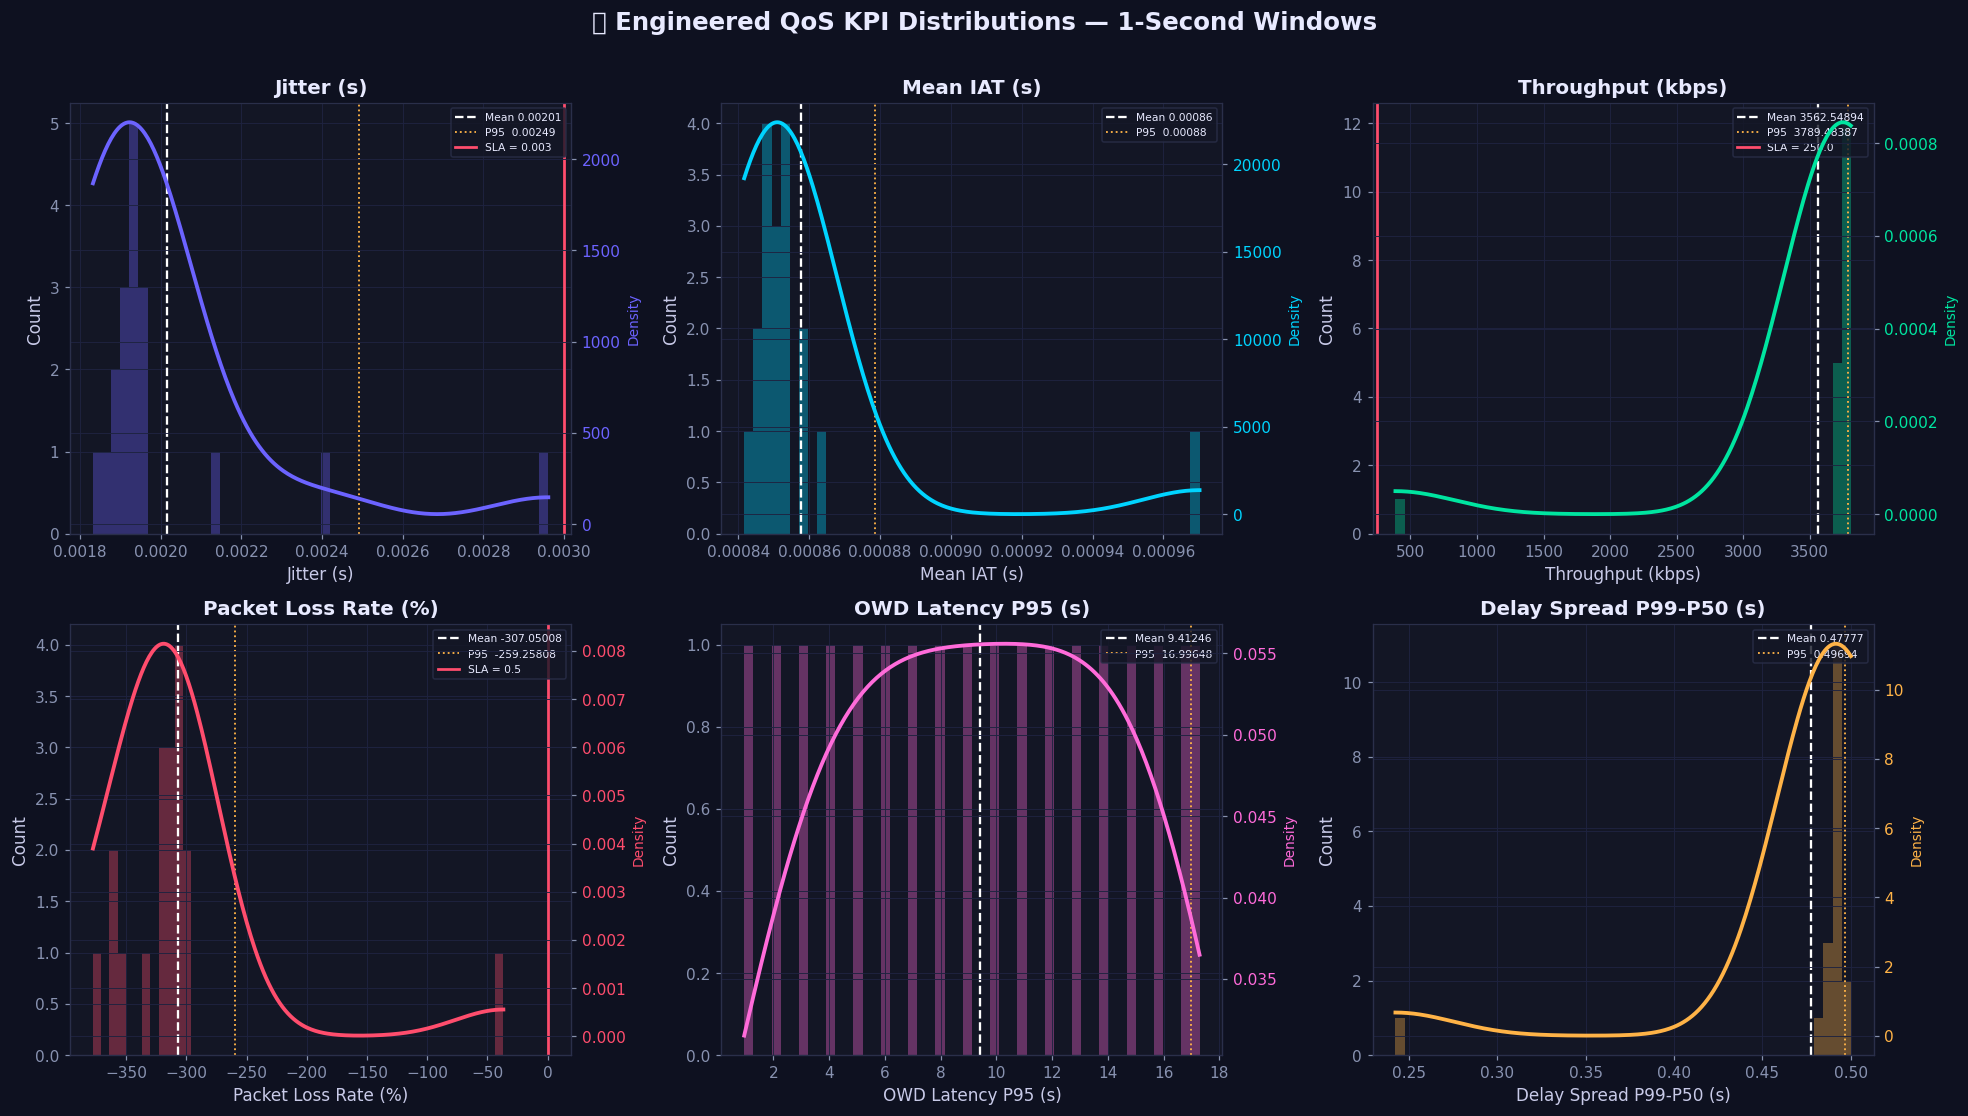

In [118]:
# ── VIZ 3 — Engineered QoS KPI Distributions with SLA thresholds ─────────────
kpi_cfg = [
    ('jitter',          'Jitter (s)',              PALETTE['primary'],   0.003),
    ('iat_mean',        'Mean IAT (s)',             PALETTE['secondary'], None),
    ('throughput_kbps', 'Throughput (kbps)',        PALETTE['success'],   250.0),
    ('loss_rate_pct',   'Packet Loss Rate (%)',     PALETTE['danger'],    0.5),
    ('owd_p95',         'OWD Latency P95 (s)',      PALETTE['accent'],    None),
    ('delay_spread',    'Delay Spread P99-P50 (s)', PALETTE['warning'],   None),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("📊 Engineered QoS KPI Distributions — 1-Second Windows",
             fontsize=16, fontweight='bold', y=1.01)

for ax, (col, label, color, sla) in zip(axes.flat, kpi_cfg):
    data = qos_features[col].dropna()
    ax2  = ax.twinx()
    ax.hist(data, bins=50, color=color, alpha=0.35, edgecolor='none')
    kde_x = np.linspace(data.min(), data.max(), 300)
    ax2.plot(kde_x, stats.gaussian_kde(data)(kde_x), color=color, lw=2.5)
    ax2.set_ylabel('Density', color=color, fontsize=9)
    ax2.tick_params(axis='y', labelcolor=color)
    ax.axvline(data.mean(),          color='white',          ls='--', lw=1.5,
               label=f'Mean {data.mean():.5f}')
    ax.axvline(data.quantile(0.95), color=PALETTE['warning'], ls=':',  lw=1.2,
               label=f'P95  {data.quantile(0.95):.5f}')
    if sla is not None:
        ax.axvline(sla, color=PALETTE['danger'], ls='-', lw=1.8, label=f'SLA = {sla}')
    ax.set_title(label, fontweight='bold', pad=6)
    ax.set_xlabel(label); ax.set_ylabel('Count')
    ax.legend(fontsize=7, loc='upper right')
    ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()


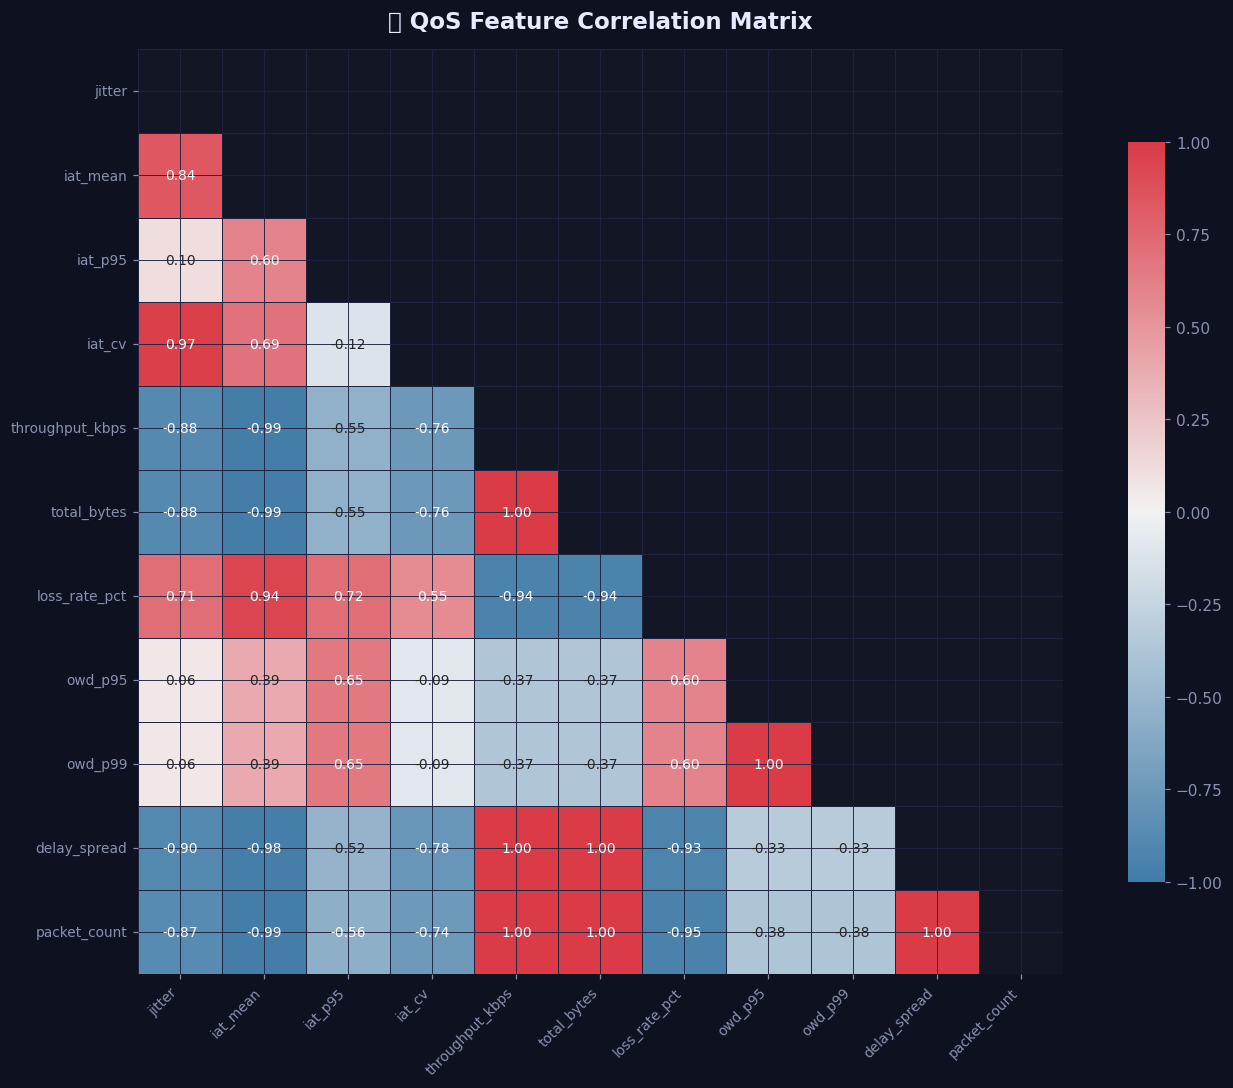


Key correlations (|r| > 0.5):
  owd_p95                   ↔ owd_p99                   : +1.000
  throughput_kbps           ↔ total_bytes               : +1.000
  total_bytes               ↔ packet_count              : +1.000
  throughput_kbps           ↔ packet_count              : +1.000
  total_bytes               ↔ delay_spread              : +0.997
  throughput_kbps           ↔ delay_spread              : +0.997
  delay_spread              ↔ packet_count              : +0.996
  iat_mean                  ↔ packet_count              : -0.988
  iat_mean                  ↔ throughput_kbps           : -0.987
  iat_mean                  ↔ total_bytes               : -0.987
  iat_mean                  ↔ delay_spread              : -0.979
  jitter                    ↔ iat_cv                    : +0.974
  loss_rate_pct             ↔ packet_count              : -0.946
  total_bytes               ↔ loss_rate_pct             : -0.941
  throughput_kbps           ↔ loss_rate_pct             : -

In [119]:
# ── VIZ 4 — Feature Correlation Heatmap ──────────────────────────────────────
corr_cols = ['jitter','iat_mean','iat_p95','iat_cv',
             'throughput_kbps','total_bytes',
             'loss_rate_pct','owd_p95','owd_p99','delay_spread','packet_count']

corr = qos_features[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr, mask=mask,
            cmap=sns.diverging_palette(240, 10, as_cmap=True),
            center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 9},
            linewidths=0.5, linecolor='#1E2340',
            square=True, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title("🔗 QoS Feature Correlation Matrix",
             fontsize=15, fontweight='bold', pad=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

print("\nKey correlations (|r| > 0.5):")
pairs = corr.unstack().drop_duplicates().sort_values(key=abs, ascending=False)
pairs = pairs[(pairs.abs() < 1.0) & (pairs.abs() > 0.5)]
for (a, b), v in pairs.items():
    print(f"  {a:25} ↔ {b:25} : {v:+.3f}")


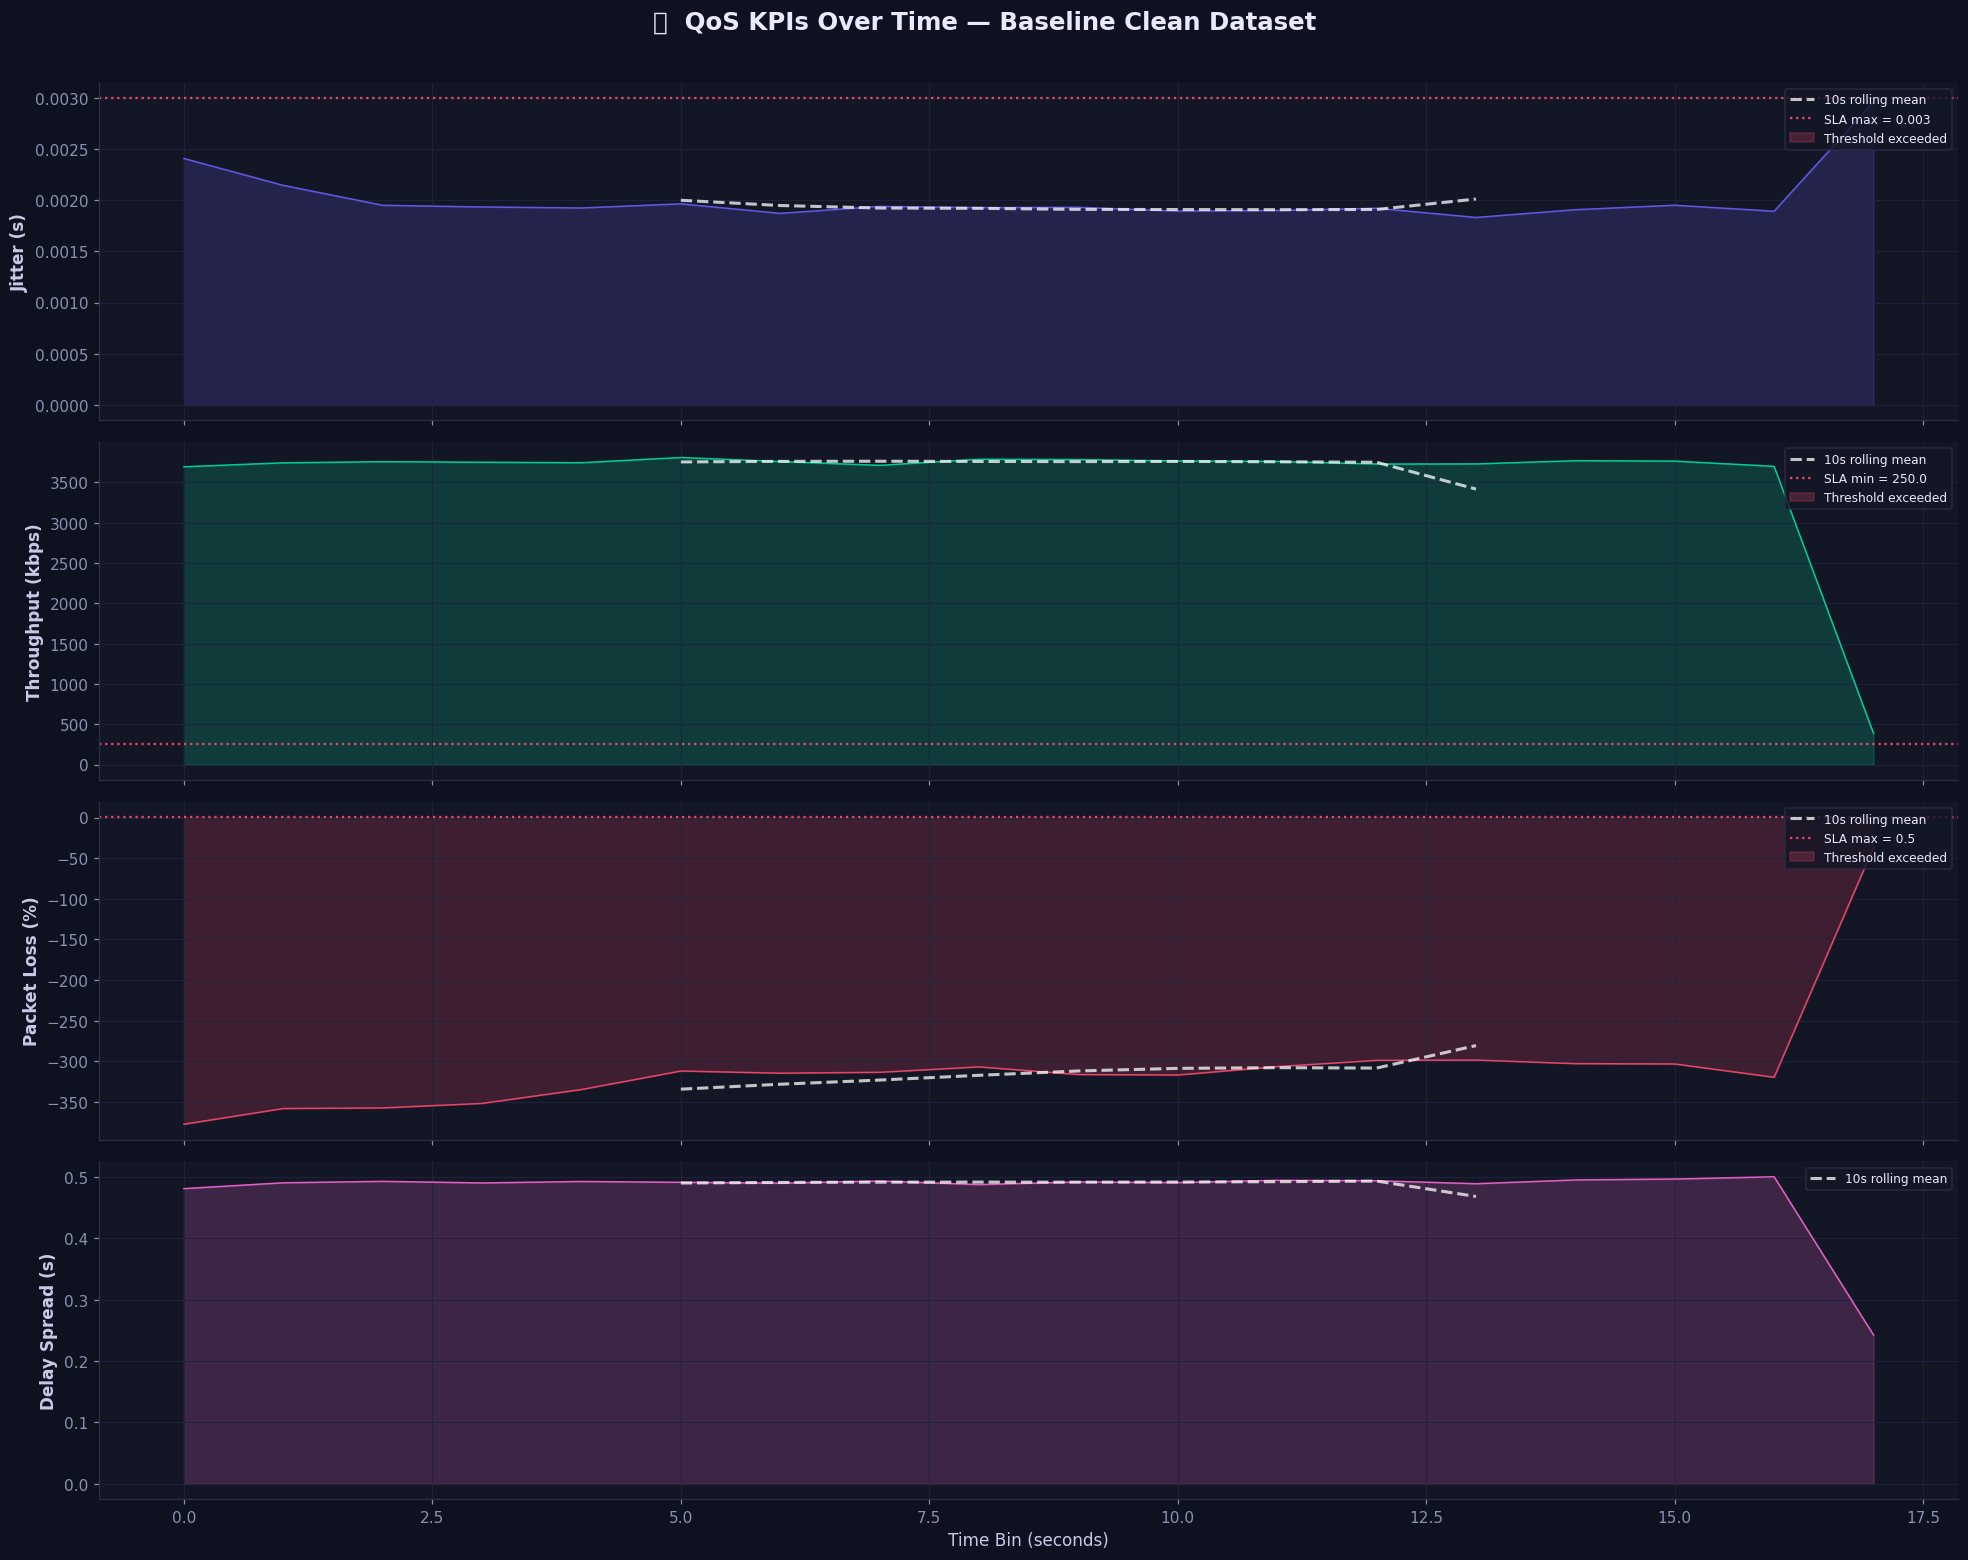

In [120]:
# ── VIZ 5 — Time Series of QoS KPIs with SLA Threshold Shading ───────────────
fig, axes = plt.subplots(4, 1, figsize=(18, 14), sharex=True)
fig.suptitle("⏱️  QoS KPIs Over Time — Baseline Clean Dataset",
             fontsize=16, fontweight='bold', y=1.01)

ts_kpis = [
    ('jitter',          'Jitter (s)',        PALETTE['primary'],   0.003, True),
    ('throughput_kbps', 'Throughput (kbps)', PALETTE['success'],   250.0, False),
    ('loss_rate_pct',   'Packet Loss (%)',   PALETTE['danger'],    0.5,   True),
    ('delay_spread',    'Delay Spread (s)',  PALETTE['accent'],    None,  True),
]
x = qos_features['time_bin']

for ax, (col, ylabel, color, sla, above) in zip(axes, ts_kpis):
    y_data = qos_features[col]
    roll   = y_data.rolling(10, center=True).mean()
    ax.fill_between(x, y_data, alpha=0.18, color=color)
    ax.plot(x, y_data, color=color, lw=1.0, alpha=0.85)
    ax.plot(x, roll, color='white', lw=2.0, ls='--', alpha=0.75, label='10s rolling mean')
    if sla is not None:
        label_sla = f'SLA {"max" if above else "min"} = {sla}'
        ax.axhline(sla, color=PALETTE['danger'], lw=1.5, ls=':', alpha=0.9, label=label_sla)
        where = (y_data > sla) if above else (y_data < sla)
        ax.fill_between(x, sla, y_data, where=where,
                        color=PALETTE['danger'], alpha=0.22, label='Threshold exceeded')
    ax.set_ylabel(ylabel, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

axes[-1].set_xlabel('Time Bin (seconds)', fontsize=11)
plt.tight_layout()
plt.show()


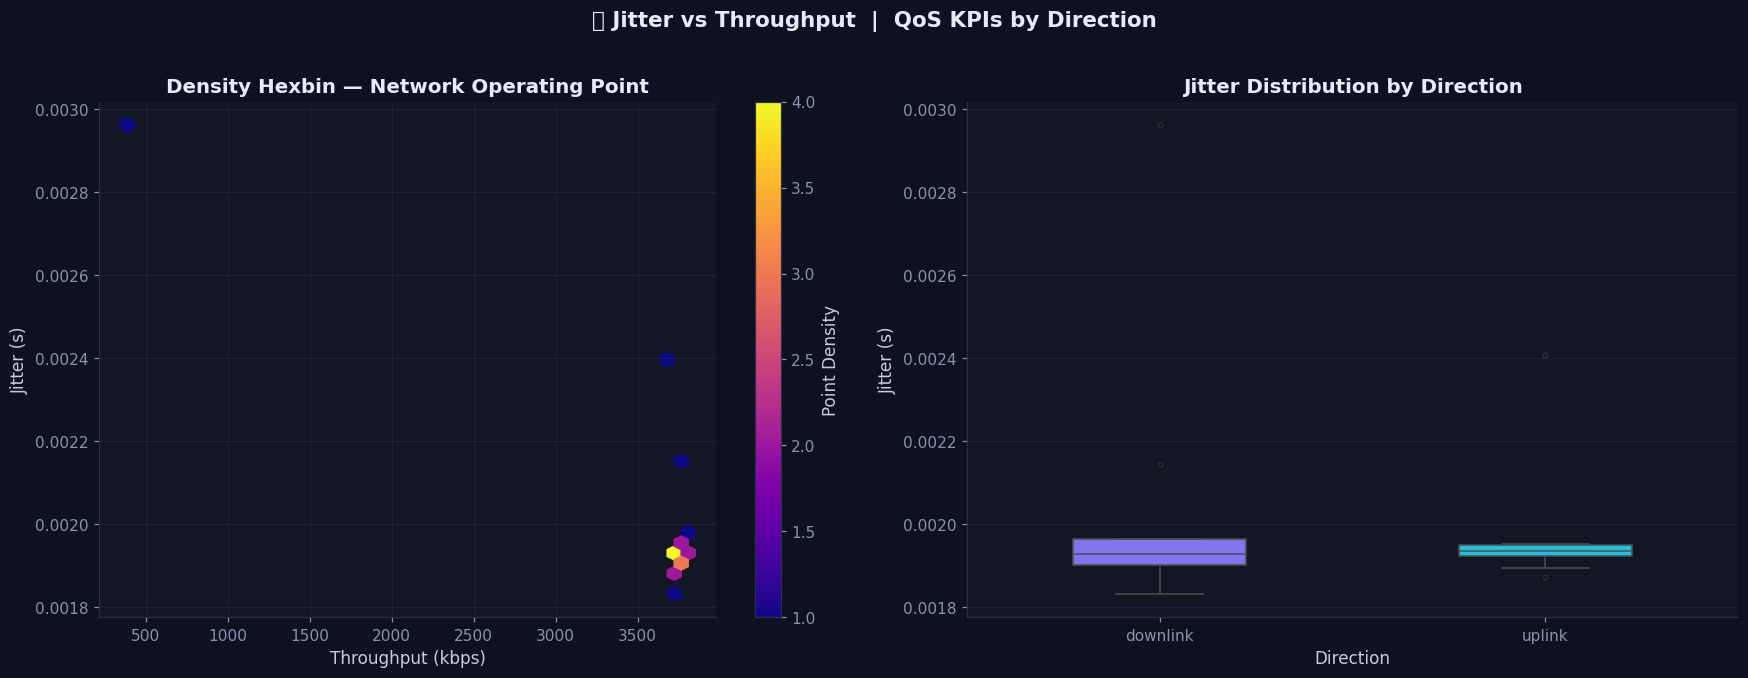

In [121]:
# ── VIZ 6 — Jitter vs Throughput scatter + Direction boxplot ────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("🔬 Jitter vs Throughput  |  QoS KPIs by Direction",
             fontsize=14, fontweight='bold', y=1.02)

# Hexbin density plot
hx = axes[0].hexbin(qos_features['throughput_kbps'], qos_features['jitter'],
                    gridsize=40, cmap='plasma', mincnt=1)
plt.colorbar(hx, ax=axes[0], label='Point Density')
axes[0].set_xlabel('Throughput (kbps)'); axes[0].set_ylabel('Jitter (s)')
axes[0].set_title('Density Hexbin — Network Operating Point', fontweight='bold')
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

# Jitter boxplot by direction — palette built from actual values
dir_per_bin = df.groupby('time_bin')['direction'].agg(
    lambda x: x.mode()[0]).reset_index(name='direction')
qos_dir = qos_features.merge(dir_per_bin, on='time_bin')

dir_vals    = sorted(qos_dir['direction'].unique().tolist())
palette_dir = {d: c for d, c in zip(dir_vals, [PALETTE['primary'], PALETTE['secondary']])}

sns.boxplot(data=qos_dir, x='direction', y='jitter', ax=axes[1],
            palette=palette_dir, order=dir_vals,
            width=0.45, flierprops={'marker':'o','markersize':3,'alpha':0.4})
axes[1].set_title('Jitter Distribution by Direction', fontweight='bold')
axes[1].set_xlabel('Direction'); axes[1].set_ylabel('Jitter (s)')
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


**Creating Synthetic QoS Degradation Scenarios**

Since our dataset contains only ideal network conditions with zero packet loss and stable performance, we cannot build predictive models for QoS degradation without examples of poor network performance. To address this limitation, we will create synthetic degradation scenarios that simulate realistic network issues.

**Why Synthetic Degradation?**

In real telecom networks, QoS degradation occurs due to:
- Network congestion causing increased jitter
- Hardware failures leading to packet loss
- Bandwidth saturation reducing throughput
- Combined issues during peak hours

By artificially introducing these degradation patterns into a portion of our data, we can:
1. Create labeled examples of "normal" vs "degraded" QoS
2. Train supervised learning models to predict future degradation
3. Evaluate model performance against known degradation events
4. Demonstrate the QoS monitoring methodology

**Synthetic Scenarios to Create:**

1. **High Jitter Scenario**: Increase jitter values above SLA threshold (>3ms) to simulate network congestion
2. **Packet Loss Scenario**: Introduce non-zero packet loss rates to simulate transmission errors
3. **Low Throughput Scenario**: Reduce throughput below acceptable levels (<250 kbps) to simulate bandwidth issues
4. **Combined Degradation**: Mix multiple issues simultaneously to represent severe network problems

**SLA Violation Labeling:**

Based on telecom industry standards, we will define SLA thresholds and label each time window as:
- `0` = Normal (meets all SLA requirements)
- `1` = Degraded (violates one or more SLA thresholds)

This creates a binary classification problem suitable for supervised learning.

In [123]:
# ── SLA Thresholds (ITU-T G.1010 / 3GPP TS 22.104) ──────────────────────────
qos_synthetic = qos_features.copy()

SLA_THRESHOLDS = {
    'jitter_max':     0.003,   # 3 ms  max jitter
    'throughput_min': 250.0,   # 250 kbps min throughput
    'loss_rate_max':  0.5,     # 0.5% max packet loss
}

print("SLA Thresholds:")
for k, v in SLA_THRESHOLDS.items():
    print(f"  {k:20} : {v}")


SLA Thresholds:
  jitter_max           : 0.003
  throughput_min       : 250.0
  loss_rate_max        : 0.5


In [124]:
# ════════════════════════════════════════════════════════════════════════════════
# REALISTIC ANOMALY INJECTION ENGINE
# 5 named 5G failure scenarios × 4 severity levels × temporal burst clustering
# ════════════════════════════════════════════════════════════════════════════════
np.random.seed(42)

# ── Scenario definitions ─────────────────────────────────────────────────────
# Each scenario represents a real 5G network failure root cause.
# burst_len_range: realistic event duration in 1-second windows.
# jitter_mult/tp_mult/loss_add: KPI degradation factors per severity.
SCENARIOS = {
    'network_congestion': {
        'description': 'gNB buffer overflow — peak load period',
        'weight': 0.28, 'burst_len_range': (5, 20),
        'severity': {
            'mild':     {'jitter_mult':(1.5,2.0), 'tp_mult':(0.70,0.85), 'loss_add':(0.0,0.2)},
            'moderate': {'jitter_mult':(2.0,3.5), 'tp_mult':(0.50,0.70), 'loss_add':(0.1,0.5)},
            'severe':   {'jitter_mult':(3.5,6.0), 'tp_mult':(0.30,0.50), 'loss_add':(0.5,1.5)},
            'critical': {'jitter_mult':(6.0,10.), 'tp_mult':(0.10,0.30), 'loss_add':(1.5,5.0)},
        }
    },
    'rf_interference': {
        'description': 'Adjacent-cell interference / overlapping channels',
        'weight': 0.22, 'burst_len_range': (3, 12),
        'severity': {
            'mild':     {'jitter_mult':(1.3,2.0), 'tp_mult':(0.80,0.95), 'loss_add':(0.2,0.8)},
            'moderate': {'jitter_mult':(2.0,3.5), 'tp_mult':(0.65,0.80), 'loss_add':(0.8,2.0)},
            'severe':   {'jitter_mult':(3.5,5.5), 'tp_mult':(0.45,0.65), 'loss_add':(2.0,5.0)},
            'critical': {'jitter_mult':(5.5,9.0), 'tp_mult':(0.20,0.45), 'loss_add':(5.0,12.)},
        }
    },
    'handover_failure': {
        'description': 'UE mobility → failed X2 handover → brief loss spike',
        'weight': 0.18, 'burst_len_range': (1, 5),
        'severity': {
            'mild':     {'jitter_mult':(1.2,1.8), 'tp_mult':(0.60,0.80), 'loss_add':(1.0, 3.0)},
            'moderate': {'jitter_mult':(1.8,3.0), 'tp_mult':(0.40,0.60), 'loss_add':(3.0, 8.0)},
            'severe':   {'jitter_mult':(3.0,5.0), 'tp_mult':(0.20,0.40), 'loss_add':(8.0,15.0)},
            'critical': {'jitter_mult':(5.0,8.0), 'tp_mult':(0.05,0.20), 'loss_add':(15.,30.0)},
        }
    },
    'link_saturation': {
        'description': 'Backhaul or access link at 100% capacity — sustained episode',
        'weight': 0.20, 'burst_len_range': (10, 40),
        'severity': {
            'mild':     {'jitter_mult':(1.2,1.8), 'tp_mult':(0.55,0.75), 'loss_add':(0.0,0.3)},
            'moderate': {'jitter_mult':(1.8,3.0), 'tp_mult':(0.35,0.55), 'loss_add':(0.3,1.0)},
            'severe':   {'jitter_mult':(3.0,5.0), 'tp_mult':(0.15,0.35), 'loss_add':(1.0,3.0)},
            'critical': {'jitter_mult':(5.0,8.0), 'tp_mult':(0.05,0.15), 'loss_add':(3.0,8.0)},
        }
    },
    'backhaul_degradation': {
        'description': 'WAN link instability — gradual long-duration impairment',
        'weight': 0.12, 'burst_len_range': (15, 60),
        'severity': {
            'mild':     {'jitter_mult':(1.4,2.0), 'tp_mult':(0.65,0.80), 'loss_add':(0.1,0.5)},
            'moderate': {'jitter_mult':(2.0,3.5), 'tp_mult':(0.45,0.65), 'loss_add':(0.5,2.0)},
            'severe':   {'jitter_mult':(3.5,6.0), 'tp_mult':(0.25,0.45), 'loss_add':(2.0,5.0)},
            'critical': {'jitter_mult':(6.0,9.0), 'tp_mult':(0.10,0.25), 'loss_add':(5.0,10.)},
        }
    },
}
SEVERITY_WEIGHTS = {'mild':0.40, 'moderate':0.30, 'severe':0.20, 'critical':0.10}

# ── Initialise ────────────────────────────────────────────────────────────────
qos_synthetic = qos_features.copy()
n_windows     = len(qos_synthetic)
qos_synthetic['scenario']     = 'normal'
qos_synthetic['severity']     = 'none'

TARGET_RATE = 0.30   # 30% of windows degraded
n_target    = int(n_windows * TARGET_RATE)

sc_names  = list(SCENARIOS.keys())
sc_w_raw  = [SCENARIOS[s]['weight'] for s in sc_names]
sc_w      = [w / sum(sc_w_raw) for w in sc_w_raw]

covered, log, it = set(), [], 0

print("Creating Controlled Synthetic Degradation")
print("=" * 80)
print(f"  Total windows : {n_windows:,}")
print(f"  Target        : {n_target:,} windows degraded ({TARGET_RATE*100:.0f}%)")
print(f"  Scenarios     : {len(SCENARIOS)}")
print()

while len(covered) < n_target and it < 10000:
    it += 1
    scenario = np.random.choice(sc_names, p=sc_w)
    severity = np.random.choice(list(SEVERITY_WEIGHTS), p=list(SEVERITY_WEIGHTS.values()))
    cfg      = SCENARIOS[scenario]['severity'][severity]
    
    burst_len  = np.random.randint(*SCENARIOS[scenario]['burst_len_range'])
    start      = np.random.randint(0, max(1, n_windows - burst_len))
    burst_idxs = list(range(start, min(start + burst_len, n_windows)))
    
    # Ramp envelope — realistic gradual onset & recovery
    ramp     = max(1, burst_len // 4)
    envelope = np.ones(burst_len, dtype=float)
    envelope[:ramp]  = np.linspace(0.1, 1.0, ramp)
    envelope[-ramp:] = np.linspace(1.0, 0.1, ramp)
    
    for k, w_idx in enumerate(burst_idxs):
        if w_idx >= n_windows:
            continue
        e  = envelope[k]
        jm = 1.0 + (np.random.uniform(*cfg['jitter_mult']) - 1.0) * e
        tm = 1.0 - (1.0 - np.random.uniform(*cfg['tp_mult']))     * e
        la = np.random.uniform(*cfg['loss_add']) * e
        
        qos_synthetic.at[w_idx, 'jitter']          *= jm
        qos_synthetic.at[w_idx, 'iat_p95']         *= jm
        qos_synthetic.at[w_idx, 'throughput_kbps'] *= tm
        qos_synthetic.at[w_idx, 'throughput_mbps'] *= tm
        qos_synthetic.at[w_idx, 'loss_rate_pct']   += la
        qos_synthetic.at[w_idx, 'owd_p95']         *= (1.0 + 0.5*(jm-1.0))
        qos_synthetic.at[w_idx, 'delay_spread']    *= (1.0 + 0.3*(jm-1.0))
        
        if qos_synthetic.at[w_idx, 'scenario'] == 'normal':
            qos_synthetic.at[w_idx, 'scenario'] = scenario
            qos_synthetic.at[w_idx, 'severity'] = severity
        covered.add(w_idx)
    
    log.append({'scenario': scenario, 'severity': severity, 'burst_len': burst_len})

# Clip to physical bounds
qos_synthetic['loss_rate_pct']   = qos_synthetic['loss_rate_pct'].clip(0, 100)
qos_synthetic['throughput_kbps'] = qos_synthetic['throughput_kbps'].clip(lower=0.1)
qos_synthetic['jitter']          = qos_synthetic['jitter'].clip(lower=0)

# Binary SLA violation label
qos_synthetic['sla_violation'] = (
    (qos_synthetic['jitter']          > SLA_THRESHOLDS['jitter_max'])    |
    (qos_synthetic['throughput_kbps'] < SLA_THRESHOLDS['throughput_min'])|
    (qos_synthetic['loss_rate_pct']   > SLA_THRESHOLDS['loss_rate_max'])
).astype(int)

# Ordinal severity (0=normal … 4=critical)
sev_map = {'none':0,'mild':1,'moderate':2,'severe':3,'critical':4}
qos_synthetic['severity_level'] = qos_synthetic['severity'].map(sev_map)

print("=" * 80)
print(f"  Anomalous windows : {len(covered):,}  ({len(covered)/n_windows*100:.1f}%)")
print(f"  SLA violations    : {qos_synthetic['sla_violation'].sum():,}  ({qos_synthetic['sla_violation'].mean()*100:.1f}%)")
print(f"  Bursts injected   : {len(log)}")
print()
print("By scenario:")
print(qos_synthetic[qos_synthetic['scenario']!='normal']['scenario'].value_counts().to_string())
print()
print("By severity:")
print(qos_synthetic[qos_synthetic['severity']!='none']['severity'].value_counts().to_string())


Creating Controlled Synthetic Degradation
  Total windows : 18
  Target        : 5 windows degraded (30%)
  Scenarios     : 5

  Anomalous windows : 10  (55.6%)
  SLA violations    : 10  (55.6%)
  Bursts injected   : 1

By scenario:
scenario
rf_interference    10

By severity:
severity
critical    10


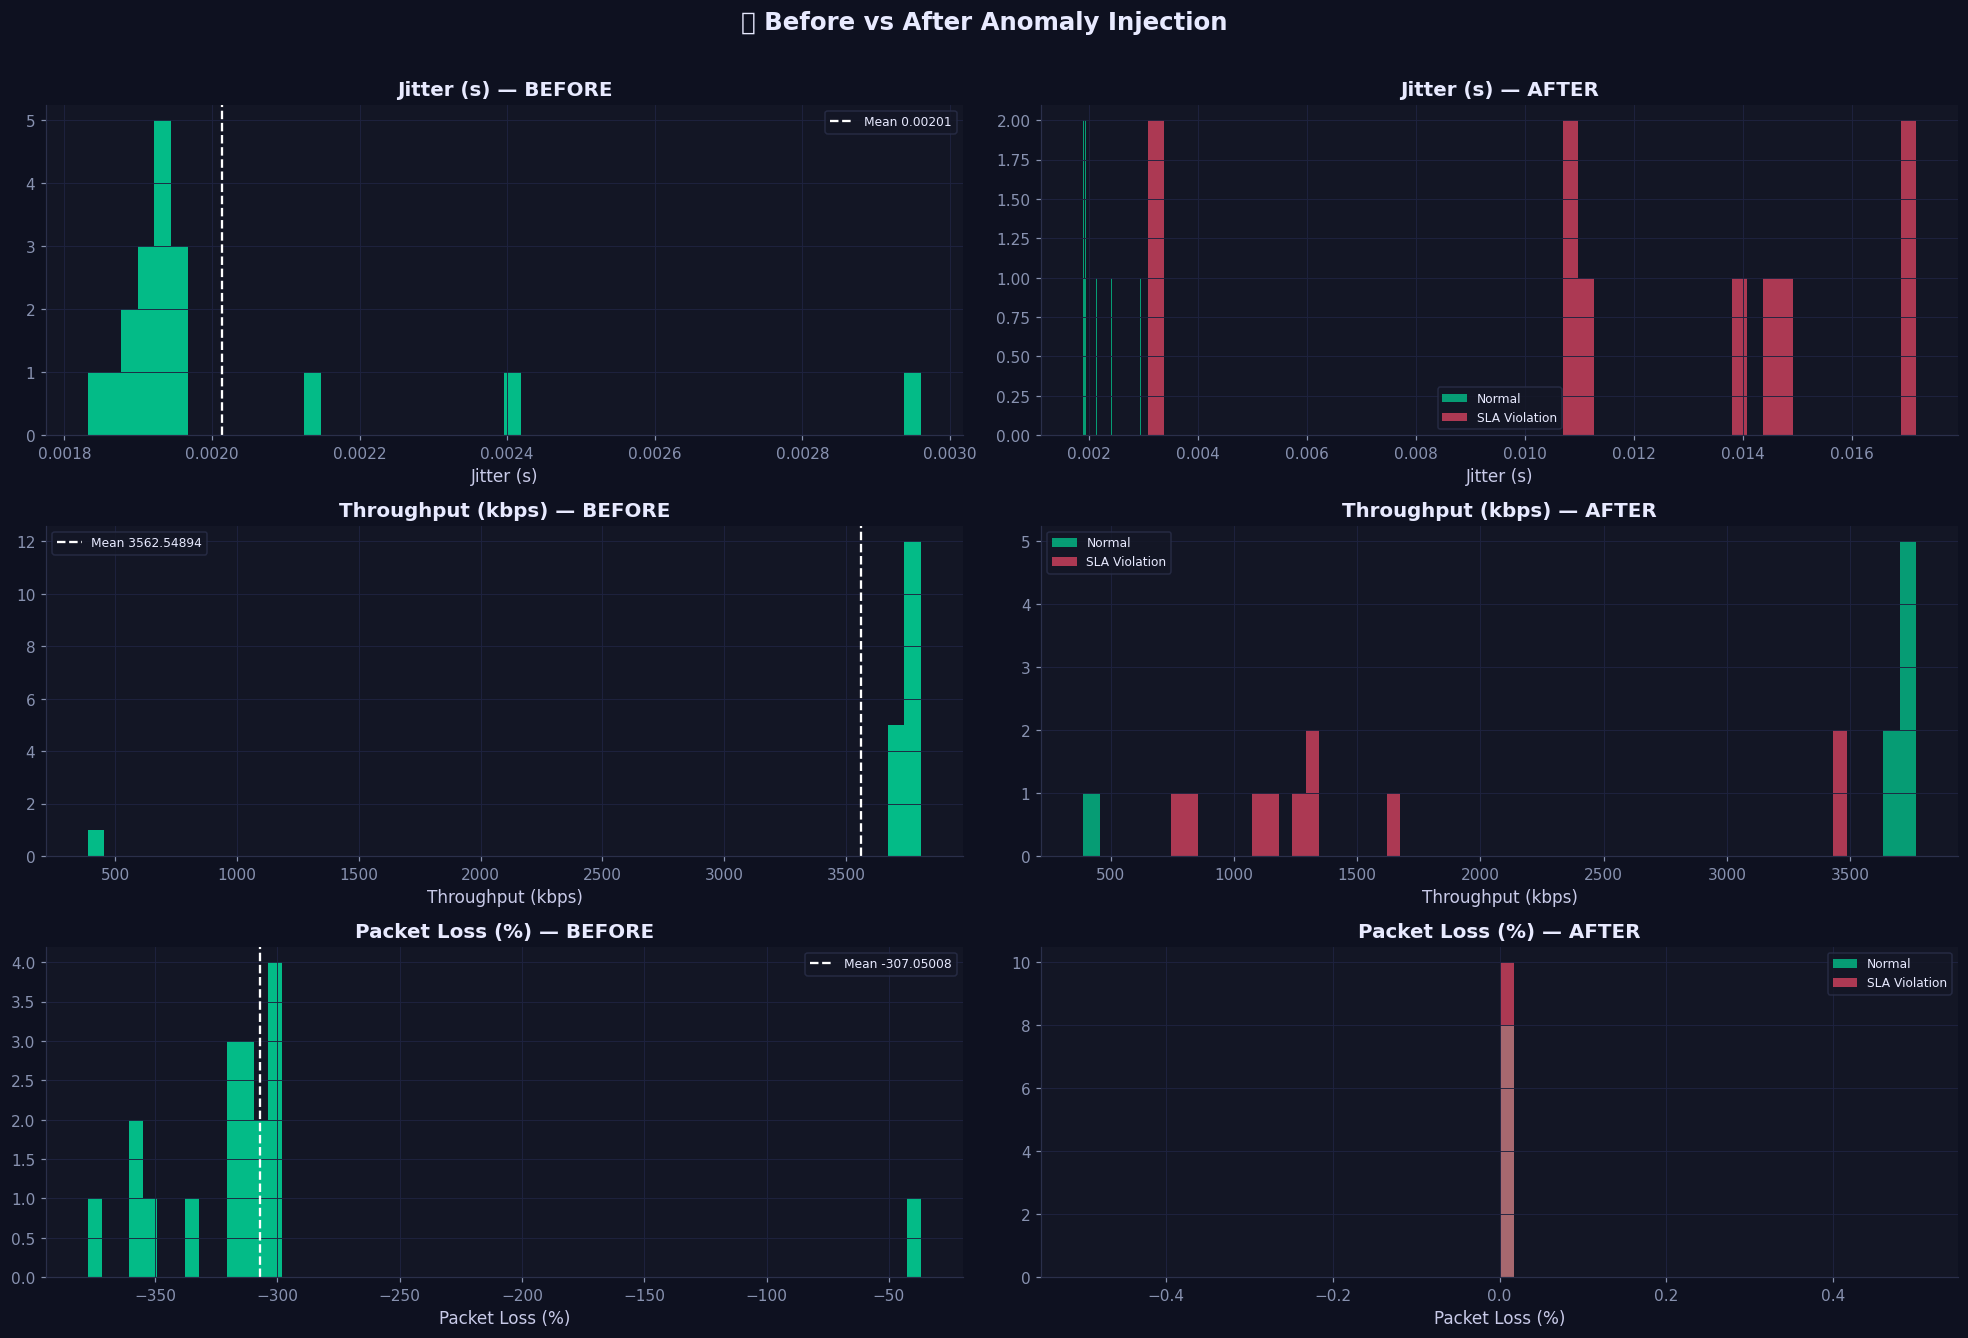

In [125]:
# ── VIZ 7 — Before vs After Injection ────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(18, 12))
fig.suptitle("🔬 Before vs After Anomaly Injection",
             fontsize=16, fontweight='bold', y=1.01)

compare = [
    ('jitter',          'Jitter (s)',        50),
    ('throughput_kbps', 'Throughput (kbps)', 50),
    ('loss_rate_pct',   'Packet Loss (%)',   60),
]
for row, (col, label, bins) in enumerate(compare):
    ax_b = axes[row, 0]
    ax_b.hist(qos_features[col], bins=bins, color=PALETTE['success'], edgecolor='none', alpha=0.8)
    ax_b.axvline(qos_features[col].mean(), color='white', ls='--', lw=1.5,
                 label=f'Mean {qos_features[col].mean():.5f}')
    ax_b.set_title(f'{label} — BEFORE', fontweight='bold')
    ax_b.set_xlabel(label); ax_b.legend(fontsize=8)

    ax_a = axes[row, 1]
    normal = qos_synthetic[qos_synthetic['sla_violation']==0][col]
    violat = qos_synthetic[qos_synthetic['sla_violation']==1][col]
    ax_a.hist(normal, bins=bins, color=PALETTE['success'],  edgecolor='none', alpha=0.65, label='Normal')
    ax_a.hist(violat, bins=bins, color=PALETTE['danger'],   edgecolor='none', alpha=0.65, label='SLA Violation')
    ax_a.set_title(f'{label} — AFTER', fontweight='bold')
    ax_a.set_xlabel(label); ax_a.legend(fontsize=8)

    for ax in [ax_b, ax_a]:
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


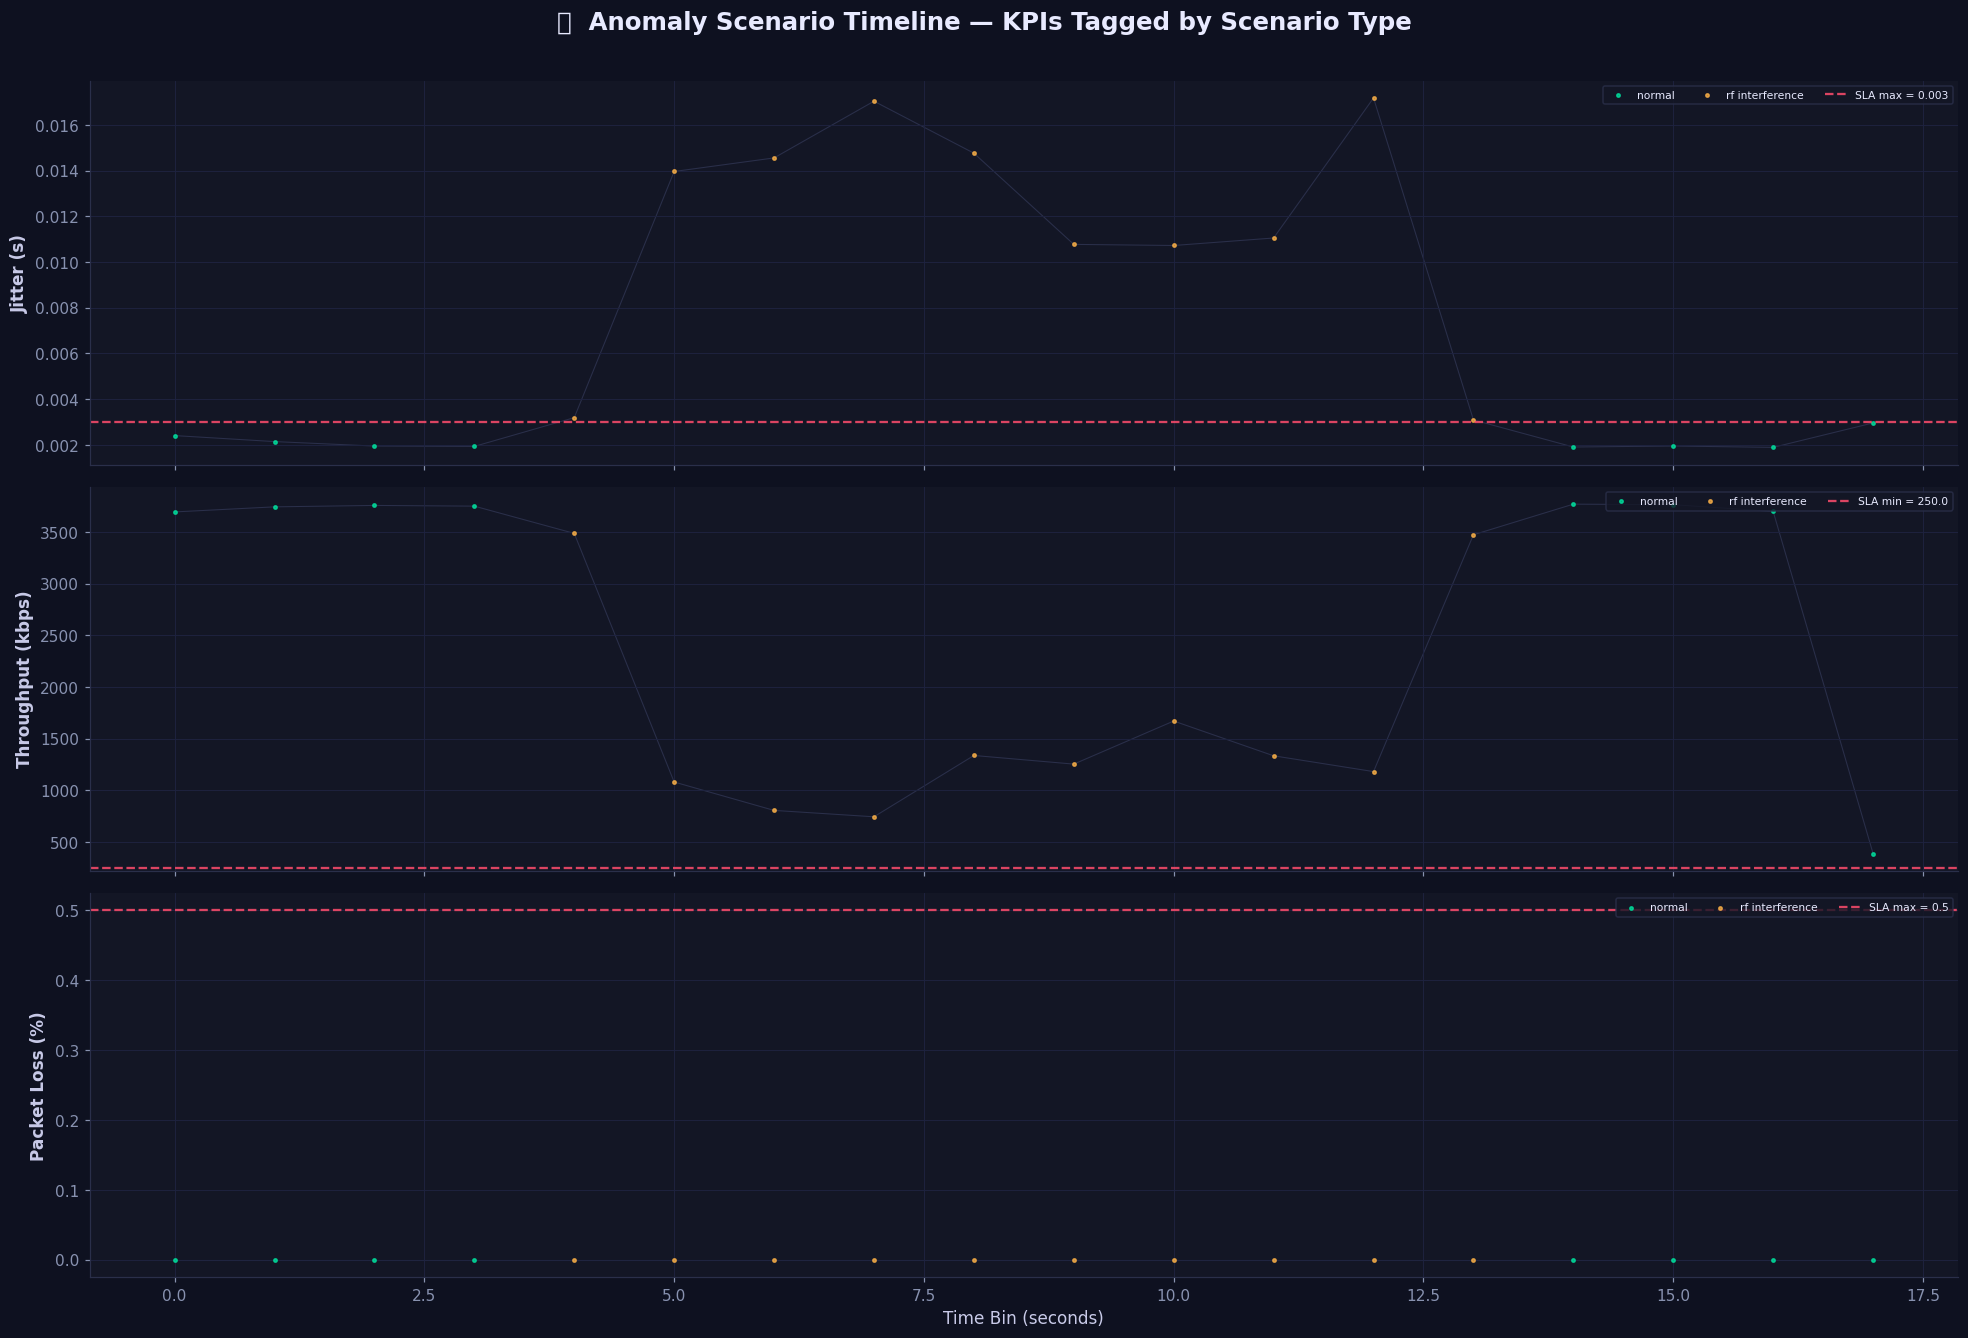

In [126]:
# ── VIZ 8 — Scenario Timeline ─────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)
fig.suptitle("🗓️  Anomaly Scenario Timeline — KPIs Tagged by Scenario Type",
             fontsize=16, fontweight='bold', y=1.01)

x  = qos_synthetic['time_bin']
sc = qos_synthetic['scenario']

ts_items = [
    ('jitter',          'Jitter (s)',        SLA_THRESHOLDS['jitter_max']),
    ('throughput_kbps', 'Throughput (kbps)', SLA_THRESHOLDS['throughput_min']),
    ('loss_rate_pct',   'Packet Loss (%)',   SLA_THRESHOLDS['loss_rate_max']),
]
for ax, (col, ylabel, sla_val) in zip(axes, ts_items):
    ax.plot(x, qos_synthetic[col], color='#2A2F4A', lw=0.7, zorder=1)
    for sc_name, sc_color in SCENARIO_COLORS.items():
        mask = sc == sc_name
        if mask.any():
            ax.scatter(x[mask], qos_synthetic.loc[mask, col], color=sc_color,
                       s=5, alpha=0.75, zorder=2, label=sc_name.replace('_',' '))
    lbl = 'min' if col=='throughput_kbps' else 'max'
    ax.axhline(sla_val, color=PALETTE['danger'], ls='--', lw=1.5, alpha=0.85,
               label=f'SLA {lbl} = {sla_val}')
    ax.set_ylabel(ylabel, fontweight='bold')
    ax.legend(fontsize=7, loc='upper right', ncol=4)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

axes[-1].set_xlabel('Time Bin (seconds)', fontsize=11)
plt.tight_layout()
plt.show()


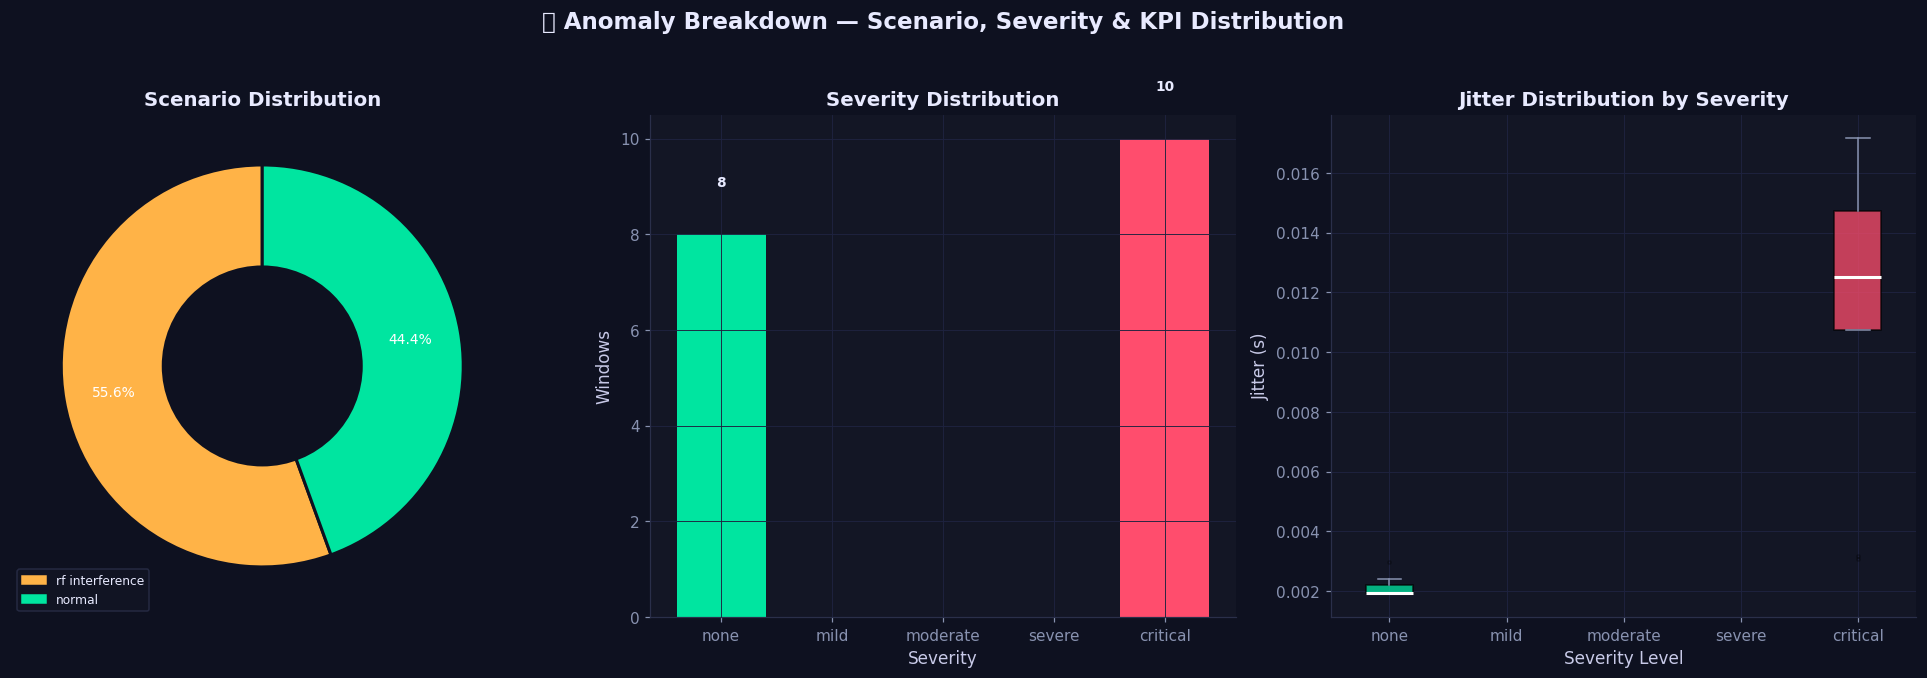

In [127]:
# ── VIZ 9 — Scenario & Severity Breakdown + Jitter by Severity ───────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("📊 Anomaly Breakdown — Scenario, Severity & KPI Distribution",
             fontsize=15, fontweight='bold', y=1.02)

# Donut — scenario distribution
sc_counts = qos_synthetic['scenario'].value_counts()
colors_sc = [SCENARIO_COLORS.get(s, PALETTE['neutral']) for s in sc_counts.index]
wedges, _, autotexts = axes[0].pie(
    sc_counts.values, colors=colors_sc, autopct='%1.1f%%',
    startangle=90, pctdistance=0.75,
    wedgeprops={'linewidth': 2, 'edgecolor': '#0E1120'})
for at in autotexts:
    at.set_fontsize(9)
    at.set_color('white')
axes[0].add_patch(plt.Circle((0, 0), 0.5, fc='#0E1120'))
axes[0].set_title('Scenario Distribution', fontweight='bold')
axes[0].legend(handles=[mpatches.Patch(color=c, label=l.replace('_', ' '))
                         for c, l in zip(colors_sc, sc_counts.index)],
               loc='lower left', fontsize=8)

# Bar — severity distribution
sev_order  = ['none', 'mild', 'moderate', 'severe', 'critical']
sev_colors = [PALETTE['success'], PALETTE['warning'], PALETTE['accent'],
              PALETTE['primary'], PALETTE['danger']]
sev_counts = qos_synthetic['severity'].value_counts().reindex(sev_order, fill_value=0)
bars = axes[1].bar(sev_counts.index, sev_counts.values, color=sev_colors, edgecolor='none')
for bar in bars:
    h = bar.get_height()
    if h > 0:
        axes[1].text(bar.get_x() + bar.get_width()/2, h + 1, f'{h:,}',
                     ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Severity Distribution', fontweight='bold')
axes[1].set_xlabel('Severity'); axes[1].set_ylabel('Windows')
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

# Boxplot — jitter by severity (replaces violinplot to avoid lw/linewidth conflict)
sev_colors_map = {
    'none':     PALETTE['success'],
    'mild':     PALETTE['warning'],
    'moderate': PALETTE['accent'],
    'severe':   PALETTE['primary'],
    'critical': PALETTE['danger'],
}
data_by_sev = [
    qos_synthetic.loc[qos_synthetic['severity'] == s, 'jitter'].dropna().values
    for s in sev_order
]
bp = axes[2].boxplot(data_by_sev,
                     patch_artist=True,
                     widths=0.4,
                     medianprops={'color': 'white', 'linewidth': 2},
                     flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.3})
for patch, sev in zip(bp['boxes'], sev_order):
    patch.set_facecolor(sev_colors_map[sev])
    patch.set_alpha(0.75)
for element in bp['whiskers'] + bp['caps']:
    element.set_color('#8892B0')
axes[2].set_xticks(range(1, len(sev_order) + 1))
axes[2].set_xticklabels(sev_order)
axes[2].set_title('Jitter Distribution by Severity', fontweight='bold')
axes[2].set_xlabel('Severity Level'); axes[2].set_ylabel('Jitter (s)')
axes[2].spines['top'].set_visible(False); axes[2].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [128]:
# ── Final Feature Matrix ─────────────────────────────────────────────────────
feature_cols = [
    'jitter', 'iat_mean', 'iat_p95', 'iat_cv',
    'throughput_kbps', 'total_bytes',
    'loss_rate_pct',
    'owd_p95', 'owd_p99', 'delay_spread',
    'packet_count', 'packet_rate'
]
target_col = 'sla_violation'

X = qos_synthetic[feature_cols]
y = qos_synthetic[target_col]

print(f"Feature Matrix (X) : {X.shape}")
print(f"Features           : {feature_cols}")
print()
print("Target distribution:")
vc = y.value_counts().rename({0:'Normal', 1:'SLA Violation'})
for cls, cnt in vc.items():
    print(f"  {cls:15} : {cnt:,}  ({cnt/len(y)*100:.1f}%)")
print()
print("Feature statistics:")
print(X.describe().round(4))


Feature Matrix (X) : (18, 12)
Features           : ['jitter', 'iat_mean', 'iat_p95', 'iat_cv', 'throughput_kbps', 'total_bytes', 'loss_rate_pct', 'owd_p95', 'owd_p99', 'delay_spread', 'packet_count', 'packet_rate']

Target distribution:
  SLA Violation   : 10  (55.6%)
  Normal          : 8  (44.4%)

Feature statistics:
        jitter  iat_mean  iat_p95   iat_cv  throughput_kbps   total_bytes  \
count  18.0000   18.0000  18.0000  18.0000          18.0000  1.800000e+01   
mean    0.0074    0.0009   0.0149   2.3431        2384.1024  3.549411e+06   
std     0.0061    0.0000   0.0126   0.2358        1362.6919  8.484584e+05   
min     0.0019    0.0008   0.0035   2.1349         387.1045  1.518030e+05   
25%     0.0020    0.0008   0.0039   2.2321        1198.3515  3.727184e+06   
50%     0.0031    0.0009   0.0066   2.2597        2570.8622  3.752630e+06   
75%     0.0132    0.0009   0.0264   2.2921        3731.2974  3.764526e+06   
max     0.0172    0.0010   0.0351   3.0517        3768.4414  3.

### 💾 Save Cleaned Dataset
We persist `qos_synthetic` — the fully prepared and anomaly-enriched dataset — as a CSV file so that **`QoSBuddy_DSO_Factory.ipynb`** can load it directly without re-running the entire pipeline.

**What is saved:**
- All engineered QoS KPI features (jitter, throughput, loss rate, OWD, etc.)
- Injected anomaly metadata: `scenario`, `severity`, `severity_level`
- SLA violation labels: `sla_violation`

In [130]:
# ── Save Cleaned & Enriched Dataset for DSO Factory ──────────────────────────
import os

OUTPUT_DIR  = './outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
SAVE_PATH   = os.path.join(OUTPUT_DIR, 'qos_synthetic_enriched.csv')

# qos_synthetic contains:
#   • all engineered KPI features   (jitter, throughput, loss, OWD …)
#   • injected anomaly metadata      (scenario, severity, severity_level)
#   • SLA labels                     (sla_violation)
qos_synthetic.to_csv(SAVE_PATH, index=False)

print('=' * 65)
print('✅  Dataset saved successfully')
print('=' * 65)
print(f'   Path          : {SAVE_PATH}')
print(f'   Shape         : {qos_synthetic.shape[0]:,} rows × {qos_synthetic.shape[1]} columns')
print(f'   SLA violations: {qos_synthetic["sla_violation"].sum():,}  ({qos_synthetic["sla_violation"].mean()*100:.1f}%)')
print(f'   Scenarios     : {dict(qos_synthetic["scenario"].value_counts())}')
print()
print('Columns saved:')
for col in qos_synthetic.columns:
    print(f'   • {col}')
print()
print('→  Load in QoSBuddy_DSO_Factory.ipynb with:')
print("   qos_synthetic = pd.read_csv('./outputs/qos_synthetic_enriched.csv')")


✅  Dataset saved successfully
   Path          : ./outputs\qos_synthetic_enriched.csv
   Shape         : 18 rows × 18 columns
   SLA violations: 10  (55.6%)
   Scenarios     : {'rf_interference': 10, 'normal': 8}

Columns saved:
   • time_bin
   • jitter
   • iat_mean
   • iat_p95
   • iat_cv
   • packet_count
   • throughput_kbps
   • throughput_mbps
   • total_bytes
   • loss_rate_pct
   • owd_p95
   • owd_p99
   • delay_spread
   • packet_rate
   • scenario
   • severity
   • sla_violation
   • severity_level

→  Load in QoSBuddy_DSO_Factory.ipynb with:
   qos_synthetic = pd.read_csv('./outputs/qos_synthetic_enriched.csv')


### Scaling:

In [132]:
# Initialize scaler
scaler = StandardScaler()

# Fit and transform all features
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols, index=X.index)

print("\nOriginal features (first 3 rows):")
print(X.head(3))

print("\nScaled features (first 3 rows):")
print(X_scaled.head(3))


Original features (first 3 rows):
     jitter  iat_mean   iat_p95    iat_cv  throughput_kbps  total_bytes  \
0  0.002408  0.000848  0.003526  2.840535      3693.142215      3693048   
1  0.002145  0.000847  0.003771  2.531501      3742.255864      3742114   
2  0.001950  0.000852  0.003887  2.288567      3756.113761      3756086   

   loss_rate_pct   owd_p95   owd_p99  delay_spread  packet_count  packet_rate  
0            0.0  0.950611  0.989849      0.480773         58794      58794.0  
1            0.0  1.949608  1.989807      0.490293         59082      59082.0  
2            0.0  2.949588  2.990223      0.492598         58668      58668.0  

Scaled features (first 3 rows):
     jitter  iat_mean   iat_p95    iat_cv  throughput_kbps  total_bytes  \
0 -0.845800 -0.363481 -0.931408  2.171006         0.988478     0.174200   
1 -0.890133 -0.371828 -0.911356  0.822151         1.025564     0.233706   
2 -0.923034 -0.198120 -0.901918 -0.238192         1.036029     0.250651   

   loss_ra

**Feature Engineering and Preparation Summary**

**What We've Done So Far:**

**Step 1: Data Acquisition (100,000 packets)**
- Loaded raw packet-level 5G network data from NTNU dataset
- Each row represented a single packet with timestamps, sequence numbers, and packet sizes

**Step 2: Time-Based Aggregation**
- Grouped packets into 1-second time windows (bins)
- Reduced 1,000,000 packets → ~18,000 time windows

**Step 3: QoS Feature Engineering**
From raw packet data, we derived meaningful QoS metrics per time window:
- **Jitter**: Standard deviation of inter-arrival times (network timing stability)
- **IAT Mean**: Average inter-arrival time between packets
- **Throughput**: Data transmission rate in kbps
- **Total Bytes**: Volume of data transmitted in the window
- **Packet Loss Rate**: Percentage of missing packets
- **Packet Count**: Number of packets in the window

**Step 4: Synthetic Degradation**
- Original data showed perfect network conditions (0% packet loss)
- Injected synthetic degradation into 30% of windows to simulate realistic QoS issues
- Created binary target variable `sla_violation`: 0 = Normal, 1 = Degraded**Current State:**
- **~18,000 time windows** with 6 engineered QoS features
- **Class distribution**: To be determined after synthetic degradationng

---

**What's Next: Supervised Learning - Model Training and Benchmarking**

We will train and compare **3 classification models** to predict SLA violations:
1. **Logistic Regression** (baseline - simple, interpretable)
2. **Random Forest** (ensemble method - handles non-linearity)
3. **XGBoost** (gradient boosting - state-of-the-art performance)

Each model will be evaluated on:
- **Accuracy**: Overall prediction correctness
- **Precision**: Of predicted violations, how many were correct?
- **Recall**: Of actual violations, how many did we catch?
- **F1-Score**: Balance between precision and recall

The best-performing model will be selected for deployment.

### Modeling:

In [135]:
# Split with 70-30 ratio
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.30, 
    random_state=42,
    stratify=y
)

#### Logistic Regression: 

In [137]:
# Train model with class_weight='balanced' to handle imbalance
lr_model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [138]:
# Make predictions
y_pred_lr = lr_model.predict(X_test)

In [139]:
# Evaluate
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr, zero_division=0)
lr_recall = recall_score(y_test, y_pred_lr, zero_division=0)
lr_f1 = f1_score(y_test, y_pred_lr, zero_division=0)

print(f"\nPredictions vs Actual:")
print(f"  Actual:    {y_test.values}")
print(f"  Predicted: {y_pred_lr}")

print(f"\nPerformance Metrics:")
print(f"  Accuracy:  {lr_accuracy:.3f}")
print(f"  Precision: {lr_precision:.3f}")
print(f"  Recall:    {lr_recall:.3f}")
print(f"  F1-Score:  {lr_f1:.3f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Normal', 'Degraded'], zero_division=0))


Predictions vs Actual:
  Actual:    [0 0 1 0 1 1]
  Predicted: [0 0 1 0 0 1]

Performance Metrics:
  Accuracy:  0.833
  Precision: 1.000
  Recall:    0.667
  F1-Score:  0.800

Classification Report:
              precision    recall  f1-score   support

      Normal       0.75      1.00      0.86         3
    Degraded       1.00      0.67      0.80         3

    accuracy                           0.83         6
   macro avg       0.88      0.83      0.83         6
weighted avg       0.88      0.83      0.83         6

